# FM 3056 - GROUP ASSIGNMENT
# Stock Clustering and Portfolio Analysis

# ......................................................................................................
#### T.R.S.K Fernando.
#### M.D.K.N.Dharmakeerthi.

<h2 style="color:blue;">Import Necessary Libraries</h2>

In [175]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.vq import kmeans,vq
from tensorflow.keras import layers, models
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings('ignore')     # Hide warnings
print('All imports successful.')

All imports successful.


<h2 style="color:blue;">Tickers list</h2>

In [176]:
#We selected 100 actively traded stocks to ensure diversification and statistical robustness.

tickers = [
    "CHTR", "FOXA", "MTCH", "PSKY", "TTWO", "APTV", "CMG", "DPZ", "GM", "HLT",
    "MAR", "NVR", "RL", "TSCO", "YUM", "CHD", "DG", "HSY", "KR", "MNST",
    "SJM", "TSN", "CTRA", "EXE", "OKE", "TRGP", "AFL", "AMP", "BAC", "BRO",
    "CFG", "CPAY", "FISV", "HBAN", "IVZ", "L", "MS", "PFG", "RF", "SYF",
    "V", "A", "BAX", "CAH", "CRL", "DXCM", "HCA", "INCY", "LLY", "MRNA",
    "RMD", "TECH", "VTRS", "ADP", "BA", "CHRW", "DAL", "EME", "FDX", "GEV",
    "HUBB", "J", "LII", "NDSN", "PAYC", "PWR", "SNA", "UAL", "VLTO", "AAPL",
    "AKAM", "APP", "CRWD", "EPAM", "GDDY", "IBM", "KEYS", "MSFT", "NVDA", "PLTR",
    "SMCI", "TDY", "TYL", "ALB", "CF", "ECL", "LYB", "PKG", "VMC", "CBRE",
    "DOC", "FRT", "MAA", "SBAC", "WELL", "ATO", "D", "ES", "LNT", "PEG", "VST"
]

print(f"Total_Tickers: {len(tickers)}")

Total_Tickers: 101


In [177]:
#Download the closed price of each tickers for the 2 year time period

prices_list = []

for ticker in tickers:
    try:
        ticket_t = yf.Ticker(ticker)
        ticket_hist = ticket_t.history(period='2y')
        prices = pd.DataFrame(ticket_hist['Close'])
        prices.columns = [ticker]
        prices_list.append(prices)
    except:
        pass
    prices_df = pd.concat(prices_list,axis=1)
prices_df.sort_index(inplace=True)

# Start date 
start_date = prices_df.index.min()

# End date
end_date = prices_df.index.max()

print(f"start_date: {start_date}")
print(f"end_date: {end_date}")

start_date: 2024-02-20 00:00:00-05:00
end_date: 2026-02-20 00:00:00-05:00


In [178]:
prices_df.tail(10)

,CHTR,FOXA,MTCH,PSKY,TTWO,APTV,CMG,DPZ,GM,HLT,...,FRT,MAA,SBAC,WELL,ATO,D,ES,LNT,PEG,VST
Date,,,,,,,,,,,,,,,,,,,,,
2026-02-06 00:00:00-05:00,231.139999,64.779999,31.629999,10.56,195.589996,82.379997,39.389999,394.880005,84.239998,314.380005,...,105.760002,132.130005,180.740005,195.919998,171.380005,62.330002,67.360001,66.690002,80.650002,149.649994
2026-02-09 00:00:00-05:00,238.250000,62.849998,32.590000,10.68,205.029999,83.370003,39.590000,392.160004,80.680000,314.029999,...,106.110001,133.580002,184.630005,197.250000,171.460007,62.360001,67.629997,66.900002,81.180000,152.970001
2026-02-10 00:00:00-05:00,248.190002,63.369999,32.490002,10.84,210.710007,85.150002,38.439999,389.730011,80.269997,323.700012,...,107.650002,136.449997,189.080002,200.839996,174.169998,63.790001,69.300003,68.010002,83.199997,159.600006
2026-02-11 00:00:00-05:00,241.070007,61.110001,31.400000,11.01,203.889999,83.760002,37.220001,384.000000,79.820000,325.130005,...,106.949997,136.029999,190.960007,207.880005,175.970001,64.650002,70.220001,68.230003,84.150002,160.149994
2026-02-12 00:00:00-05:00,238.080002,56.430000,29.920000,10.25,190.360001,83.000000,35.840000,381.779999,79.930000,322.170013,...,104.750000,133.440002,199.289993,208.139999,177.770004,65.120003,70.320000,69.680000,84.540001,163.100006
2026-02-13 00:00:00-05:00,239.089996,56.349998,30.500000,10.32,193.669998,85.199997,36.299999,375.500000,81.080002,314.619995,...,104.800003,135.550003,200.770004,210.720001,179.250000,66.510002,73.360001,71.190002,86.370003,171.490005
2026-02-17 00:00:00-05:00,237.009995,56.430000,30.180000,10.83,193.869995,82.769997,37.880001,373.500000,81.220001,317.820007,...,106.209999,134.410004,203.119995,215.479996,180.240005,65.650002,73.029999,71.099998,86.949997,173.679993
2026-02-18 00:00:00-05:00,239.139999,57.169998,30.280001,11.12,199.130005,83.809998,38.720001,382.989990,83.669998,315.880005,...,105.449997,135.119995,197.460007,208.589996,178.119995,64.720001,71.720001,69.529999,84.360001,170.570007
2026-02-19 00:00:00-05:00,231.539993,56.160000,30.690001,10.94,201.369995,80.459999,37.970001,385.130005,81.470001,312.730011,...,105.870003,135.070007,198.289993,208.009995,178.970001,65.459999,73.669998,70.010002,85.680000,172.500000


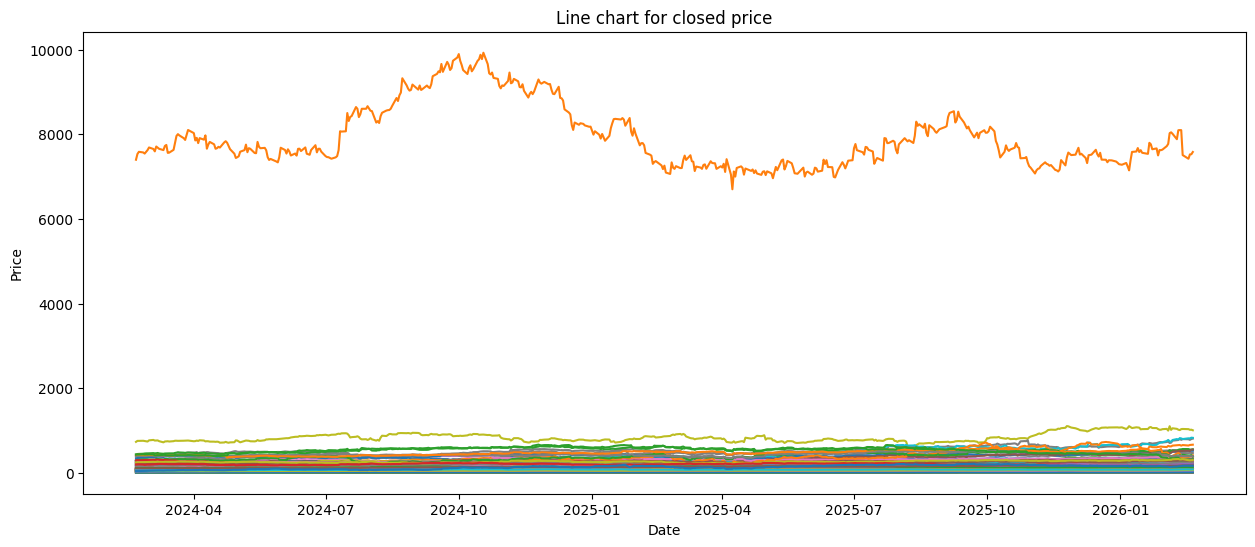

In [179]:
plt.figure(figsize=(15, 6))
plt.plot(prices_df)
plt.title('Line chart for closed price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [180]:
# Getting the name of the stock with the highest price
highest_stock = prices_df.max().idxmax()
print(highest_stock)

NVR


<h2 style="color:blue;">Remove the outlier</h2>

In [181]:
updated_tickers = [
    "CHTR", "FOXA", "MTCH", "PSKY", "TTWO", "APTV", "CMG", "DPZ", "GM", "HLT",
    "MAR", "RL", "TSCO", "YUM", "CHD", "DG", "HSY", "KR", "MNST",
    "SJM", "TSN", "CTRA", "EXE", "OKE", "TRGP", "AFL", "AMP", "BAC", "BRO",
    "CFG", "CPAY", "FISV", "HBAN", "IVZ", "L", "MS", "PFG", "RF", "SYF",
    "V", "A", "BAX", "CAH", "CRL", "DXCM", "HCA", "INCY", "LLY", "MRNA",
    "RMD", "TECH", "VTRS", "ADP", "BA", "CHRW", "DAL", "EME", "FDX", "GEV",
    "HUBB", "J", "LII", "NDSN", "PAYC", "PWR", "SNA", "UAL", "VLTO", "AAPL",
    "AKAM", "APP", "CRWD", "EPAM", "GDDY", "IBM", "KEYS", "MSFT", "NVDA", "PLTR",
    "SMCI", "TDY", "TYL", "ALB", "CF", "ECL", "LYB", "PKG", "VMC", "CBRE",
    "DOC", "FRT", "MAA", "SBAC", "WELL", "ATO", "D", "ES", "LNT", "PEG", "VST"
]

print(f"Total_Tickers: {len(updated_tickers)}")

Total_Tickers: 100


In [182]:
#Download the closed price of each tickers for the 2 year time period after removing outlier

prices_list = []

for ticker in updated_tickers:
    try:
        ticket_t = yf.Ticker(ticker)
        ticket_hist = ticket_t.history(period='2y')
        prices = pd.DataFrame(ticket_hist['Close'])
        prices.columns = [ticker]
        prices_list.append(prices)
    except:
        pass
    prices_df = pd.concat(prices_list,axis=1)
prices_df.sort_index(inplace=True)

# Start date 
start_date = prices_df.index.min()

# End date
end_date = prices_df.index.max()

print(f"start_date: {start_date}")
print(f"end_date: {end_date}")

start_date: 2024-02-20 00:00:00-05:00
end_date: 2026-02-20 00:00:00-05:00


In [183]:
prices_df.tail(10)

,CHTR,FOXA,MTCH,PSKY,TTWO,APTV,CMG,DPZ,GM,HLT,...,FRT,MAA,SBAC,WELL,ATO,D,ES,LNT,PEG,VST
Date,,,,,,,,,,,,,,,,,,,,,
2026-02-06 00:00:00-05:00,231.139999,64.779999,31.629999,10.56,195.589996,82.379997,39.389999,394.880005,84.239998,314.380005,...,105.760002,132.130005,180.740005,195.919998,171.380005,62.330002,67.360001,66.690002,80.650002,149.649994
2026-02-09 00:00:00-05:00,238.250000,62.849998,32.590000,10.68,205.029999,83.370003,39.590000,392.160004,80.680000,314.029999,...,106.110001,133.580002,184.630005,197.250000,171.460007,62.360001,67.629997,66.900002,81.180000,152.970001
2026-02-10 00:00:00-05:00,248.190002,63.369999,32.490002,10.84,210.710007,85.150002,38.439999,389.730011,80.269997,323.700012,...,107.650002,136.449997,189.080002,200.839996,174.169998,63.790001,69.300003,68.010002,83.199997,159.600006
2026-02-11 00:00:00-05:00,241.070007,61.110001,31.400000,11.01,203.889999,83.760002,37.220001,384.000000,79.820000,325.130005,...,106.949997,136.029999,190.960007,207.880005,175.970001,64.650002,70.220001,68.230003,84.150002,160.149994
2026-02-12 00:00:00-05:00,238.080002,56.430000,29.920000,10.25,190.360001,83.000000,35.840000,381.779999,79.930000,322.170013,...,104.750000,133.440002,199.289993,208.139999,177.770004,65.120003,70.320000,69.680000,84.540001,163.100006
2026-02-13 00:00:00-05:00,239.089996,56.349998,30.500000,10.32,193.669998,85.199997,36.299999,375.500000,81.080002,314.619995,...,104.800003,135.550003,200.770004,210.720001,179.250000,66.510002,73.360001,71.190002,86.370003,171.490005
2026-02-17 00:00:00-05:00,237.009995,56.430000,30.180000,10.83,193.869995,82.769997,37.880001,373.500000,81.220001,317.820007,...,106.209999,134.410004,203.119995,215.479996,180.240005,65.650002,73.029999,71.099998,86.949997,173.679993
2026-02-18 00:00:00-05:00,239.139999,57.169998,30.280001,11.12,199.130005,83.809998,38.720001,382.989990,83.669998,315.880005,...,105.449997,135.119995,197.460007,208.589996,178.119995,64.720001,71.720001,69.529999,84.360001,170.570007
2026-02-19 00:00:00-05:00,231.539993,56.160000,30.690001,10.94,201.369995,80.459999,37.970001,385.130005,81.470001,312.730011,...,105.870003,135.070007,198.289993,208.009995,178.970001,65.459999,73.669998,70.010002,85.680000,172.500000


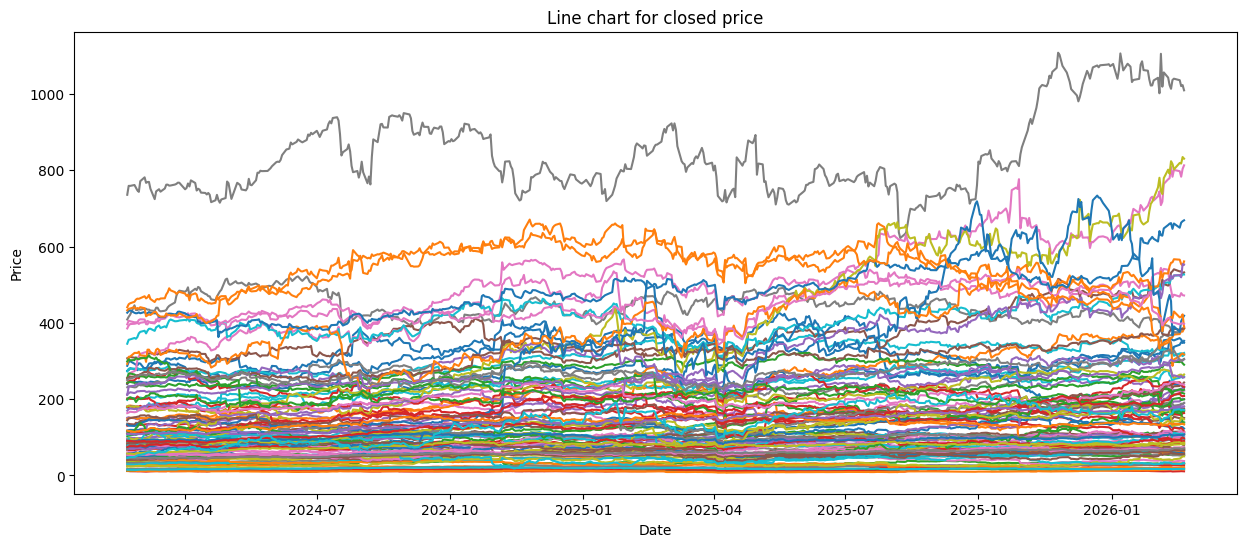

In [184]:
plt.figure(figsize=(15, 6))
plt.plot(prices_df)
plt.title('Line chart for closed price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [185]:
# Take the average closing price of each stock.
#Average price captures the general price level over the 2-year sample
avg_prices = prices_df.mean()

# Convert to DataFrame
price_df = avg_prices.reset_index()
price_df.columns = ['Stock', 'Avg_Price']

In [186]:
price_df

,Stock,Avg_Price
0,CHTR,310.476453
1,FOXA,49.258328
2,MTCH,32.501478
3,PSKY,12.074276
4,TTWO,197.475876
...,...,...
95,D,53.746794
96,ES,60.982403
97,LNT,58.130147
98,PEG,78.099518


In [187]:
# Sort by average price
price_df = price_df.sort_values(by='Avg_Price').reset_index(drop=True)

# Create 5 price-based classes using average price
price_df['Price_Class'] = pd.qcut(
    price_df['Avg_Price'],
    q=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Top']
)

In [188]:
# Printing stocks related to each group separately
for p_class in price_df['Price_Class'].unique():
    print(f"--- {p_class} ---")
    stocks = price_df[price_df['Price_Class'] == p_class]['Stock'].tolist()
    print(stocks)
    print("\n")

--- Very Low ---
['VTRS', 'PSKY', 'HBAN', 'IVZ', 'DOC', 'RF', 'CTRA', 'BAX', 'MTCH', 'CFG', 'BAC', 'FOXA', 'SMCI', 'CMG', 'GM', 'TSCO', 'D', 'DAL', 'TSN', 'MRNA']


--- Low ---
['LNT', 'SYF', 'MNST', 'KR', 'ES', 'TECH', 'LYB', 'APTV', 'INCY', 'PEG', 'UAL', 'PFG', 'OKE', 'CF', 'DXCM', 'L', 'AKAM', 'PLTR', 'EXE', 'BRO']


--- Medium ---
['ALB', 'CHD', 'FRT', 'VLTO', 'AFL', 'SJM', 'DG', 'CHRW', 'MS', 'CBRE', 'J', 'A', 'CAH', 'VST', 'NVDA', 'YUM', 'MAA', 'WELL', 'ATO', 'GDDY']


--- High ---
['FISV', 'TRGP', 'KEYS', 'HSY', 'CRL', 'BA', 'PAYC', 'TTWO', 'PKG', 'EPAM', 'SBAC', 'AAPL', 'IBM', 'NDSN', 'RMD', 'HLT', 'RL', 'ECL', 'FDX', 'MAR']


--- Top ---
['VMC', 'ADP', 'CHTR', 'SNA', 'APP', 'V', 'CPAY', 'PWR', 'HCA', 'CRWD', 'GEV', 'HUBB', 'MSFT', 'DPZ', 'AMP', 'TDY', 'EME', 'TYL', 'LII', 'LLY']




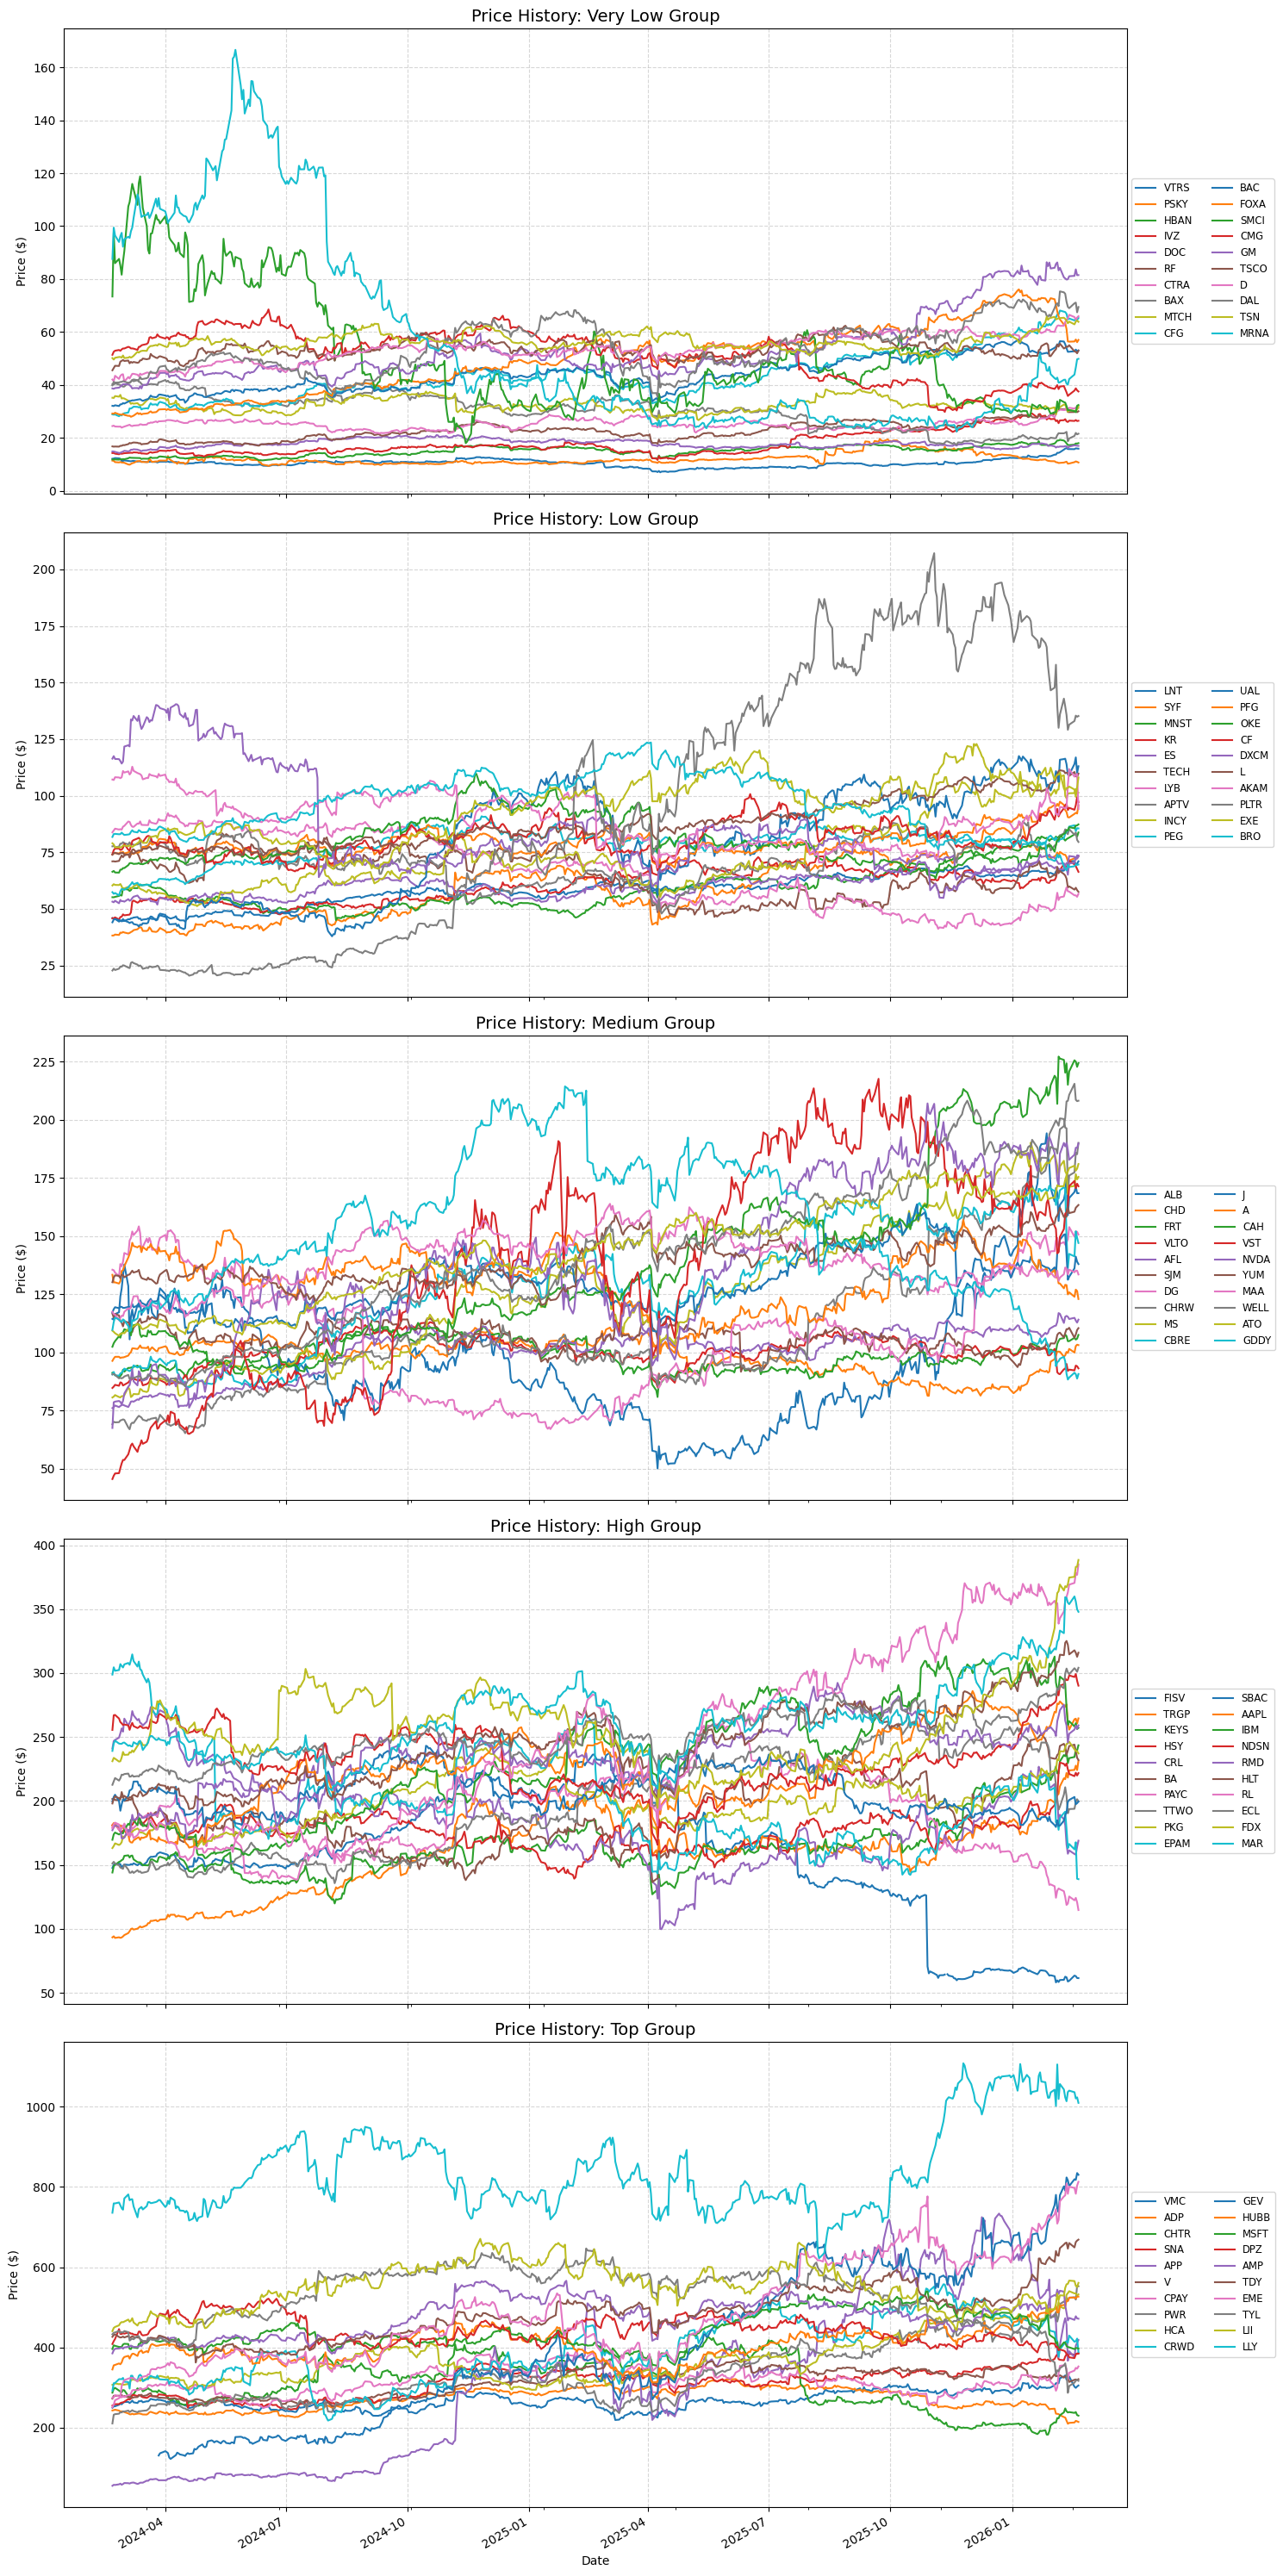

In [189]:
# Draw a chart with a legend for each category.
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(15, 30), sharex=True)

# Labels
classes = ['Very Low', 'Low', 'Medium', 'High', 'Top']

for i, p_class in enumerate(classes):
    # Selecting stocks belonging to the relevant class
    stocks_in_class = price_df[price_df['Price_Class'] == p_class]['Stock'].tolist()

    # Plotting the prices of those stocks
    prices_df[stocks_in_class].plot(ax=axes[i])

    # Setting the Legend
    axes[i].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small', ncol=2)

    # Setting the chart title and labels
    axes[i].set_title(f'Price History: {p_class} Group', fontsize=14)
    axes[i].set_ylabel('Price ($)')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<h2 style="color:blue;">Volatility Profile</h2>

In [190]:
volatility = pd.DataFrame()

# Calculating daily simple returns using pct_change()
daily_returns = prices_df.pct_change()

# Calculating the standard deviation of daily simple returns
daily_std = daily_returns.std()

#Assume that 5_trading days = 1 week
volatility['Weekly_Volatility']    = daily_std * np.sqrt(5)

#Assume that 21_trading days = 1 month
volatility['Monthly_Volatility']   = daily_std * np.sqrt(21)

#Assume that 63_trading days = 1 quarter
volatility['Quarterly_Volatility'] = daily_std * np.sqrt(63)

In [191]:
volatility.head(10)

,Weekly_Volatility,Monthly_Volatility,Quarterly_Volatility
CHTR,0.054973,0.112662,0.195136
FOXA,0.036517,0.074838,0.129623
MTCH,0.051149,0.104824,0.181560
PSKY,0.077354,0.158528,0.274579
TTWO,0.040222,0.082430,0.142772
APTV,0.052651,0.107902,0.186891
CMG,0.049407,0.101253,0.175376
DPZ,0.038945,0.079814,0.138241
GM,0.049178,0.100784,0.174563
HLT,0.032630,0.066871,0.115824


In [192]:
# Since the index of the volatility DataFrame and the 'Stock' column of price_df are the same, we can add them like this:
volatility_to_merge = volatility.copy()
volatility_to_merge['Stock'] = volatility_to_merge.index

# Combining Price data and Volatility data
merged_df = pd.merge(price_df, volatility_to_merge, on='Stock')

# Viewing the average of Volatility by Price_Class
vols_by_class = merged_df.groupby('Price_Class')[['Weekly_Volatility', 'Monthly_Volatility', 'Quarterly_Volatility']].mean()

print(vols_by_class)

             Weekly_Volatility  Monthly_Volatility  Quarterly_Volatility
Price_Class                                                             
Very Low              0.052030            0.106629              0.184686
Low                   0.045849            0.093962              0.162748
Medium                0.042731            0.087573              0.151681
High                  0.044202            0.090587              0.156902
Top                   0.047668            0.097690              0.169205


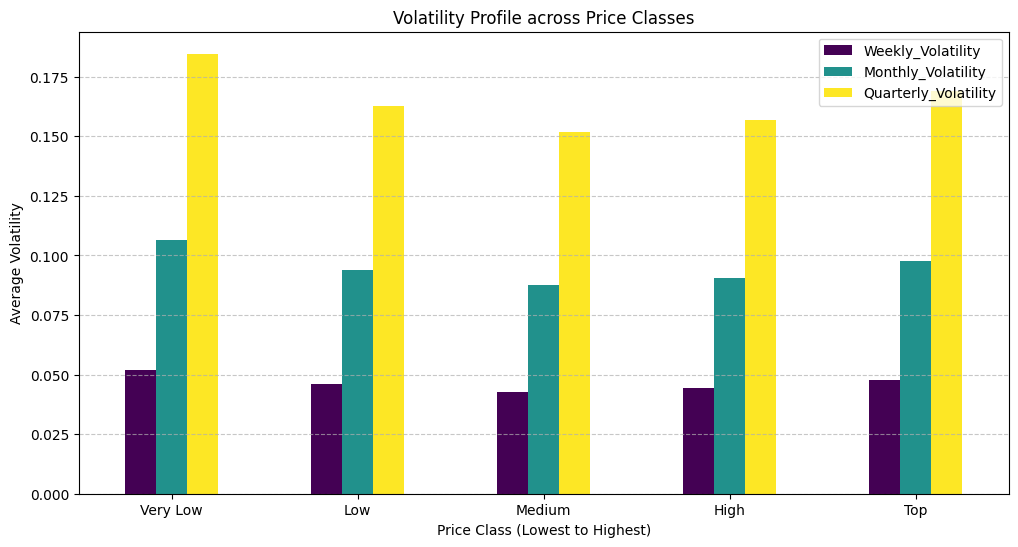

In [193]:
#plotting average volatility for each price class

vols_by_class.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Volatility Profile across Price Classes')
plt.ylabel('Average Volatility')
plt.xlabel('Price Class (Lowest to Highest)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.show()

Sorted Average Volatility by Price Class:
             Weekly_Volatility  Monthly_Volatility  Quarterly_Volatility
Price_Class                                                             
Medium                0.042731            0.087573              0.151681
High                  0.044202            0.090587              0.156902
Low                   0.045849            0.093962              0.162748
Top                   0.047668            0.097690              0.169205
Very Low              0.052030            0.106629              0.184686


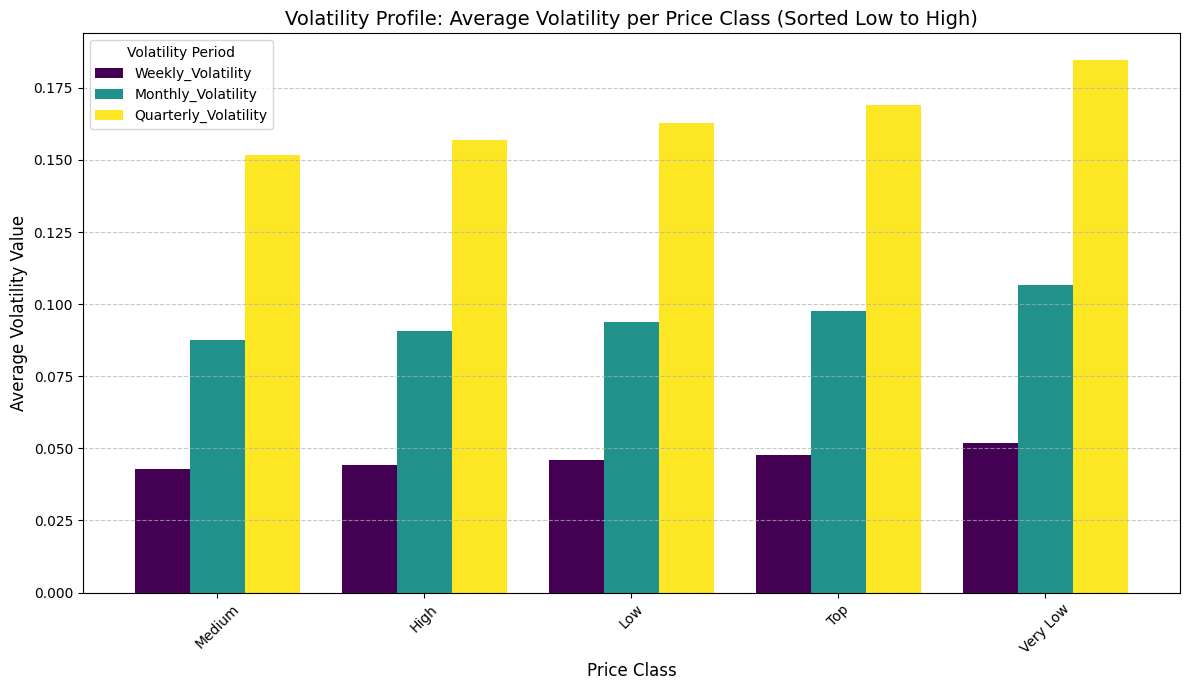

In [194]:
import seaborn as sns

# Sorting from lowest to highest value according to Monthly Volatility
vols_by_class_sorted = vols_by_class.sort_values(by='Monthly_Volatility')

# Viewing the result as a table
print("Sorted Average Volatility by Price Class:")
print(vols_by_class_sorted)

# Plotting the result
plt.figure(figsize=(12, 7))
vols_by_class_sorted.plot(kind='bar', width=0.8, ax=plt.gca(), colormap='viridis')

plt.title('Volatility Profile: Average Volatility per Price Class (Sorted Low to High)', fontsize=14)
plt.ylabel('Average Volatility Value', fontsize=12)
plt.xlabel('Price Class', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Volatility Period')
plt.tight_layout()
plt.show()

<h2 style="color:blue;">Single Feature Clustering</h2>

### Clustering  based Monthly Volatilities

The main reason for choosing monthly volatility is to reduce the noise in daily data and identify a more stable medium-term risk profile. 
In clustering, companies must have a clear difference in their behavior to be separated into different groups, and since weekly data is 
too short and quarterly data is not enough, monthly data (Monthly Volatility) is considered a more balanced and practical indicator.

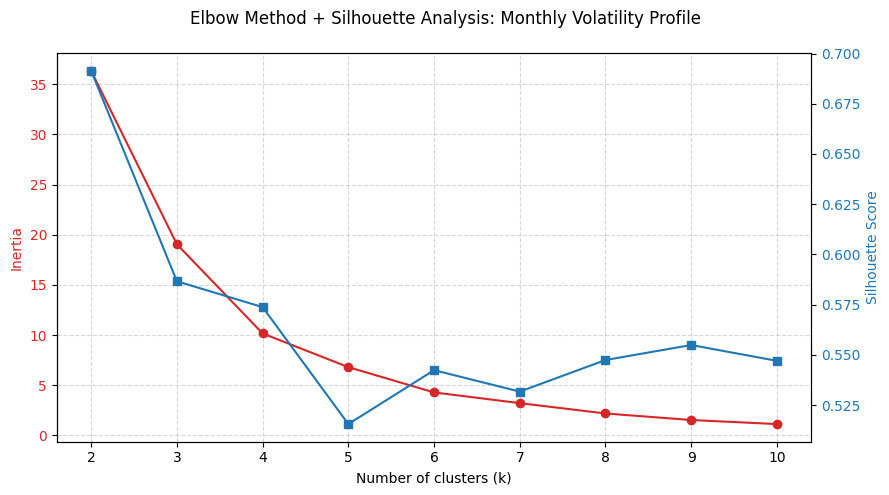

Optimal number of clusters based on silhouette score: 2


In [195]:
# Data Preparation
#------------------------------------------------------------------

# Taking only Volatility Data
X_vol = volatility['Monthly_Volatility'].dropna().values.reshape(-1, 1)
X_vol_scaled = StandardScaler().fit_transform(X_vol)

# Range of clusters (silhouette requires at least 2)
K_range = range(2, 11)  # from 2 to 10 clusters
inertia = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_vol_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_vol_scaled, labels))

# Plot both metrics on the same figure with a secondary y‑axis
fig, ax1 = plt.subplots(figsize=(9, 5))

color = 'tab:red'
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia', color=color)
ax1.plot(K_range, inertia, 'o-', color=color, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, silhouette_scores, 's-', color=color, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

fig.suptitle('Elbow Method + Silhouette Analysis: Monthly Volatility Profile', fontsize=12)
fig.tight_layout()
plt.show()

# Find the optimal k according to silhouette score
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters based on silhouette score: {optimal_k}")

### K-Mean Approach

K-Means Silhouette Score: 0.6913


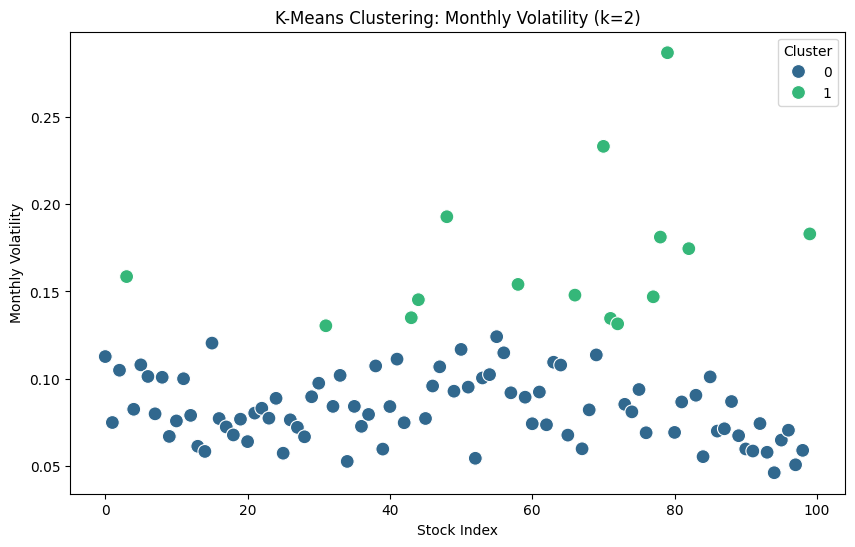

In [196]:
# Creating the Model
n_clusters = 2
kmeans_model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

# Fitting and getting labels
km_labels = kmeans_model.fit_predict(X_vol_scaled)

# Viewing the Silhouette Score
km_score = silhouette_score(X_vol_scaled, km_labels)
print(f"K-Means Silhouette Score: {km_score:.4f}")

# Plotting
plt.figure(figsize=(10, 6))
sns.scatterplot(x=range(len(X_vol_scaled)), y=volatility['Monthly_Volatility'].dropna(),
                hue=km_labels, palette='viridis', s=100)
plt.title(f'K-Means Clustering: Monthly Volatility (k={n_clusters})')
plt.xlabel('Stock Index')
plt.ylabel('Monthly Volatility')
plt.legend(title='Cluster')
plt.show()

### Deep Clustering

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Deep Clustering Silhouette Score: 0.7319


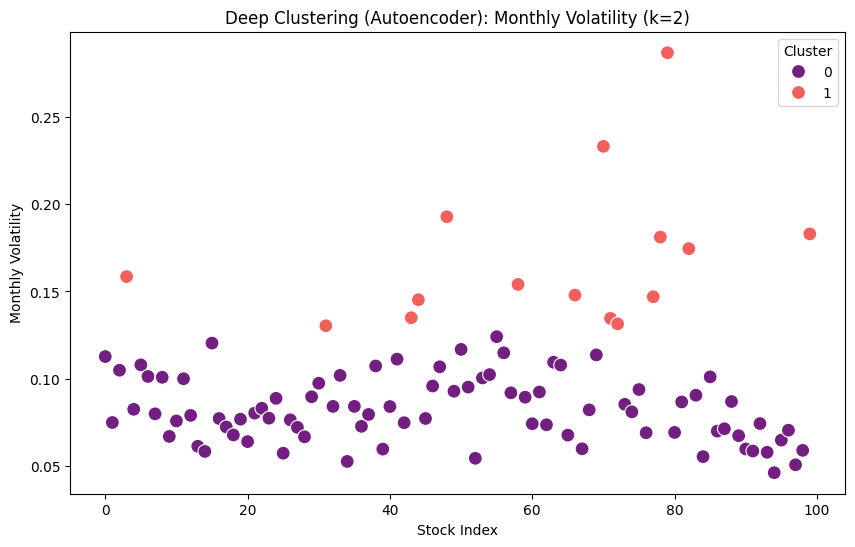

In [197]:
# Creating the Architecture of the Autoencoder

input_dim = 1
latent_dim = 1 #One feature compressed to 1

input_layer = layers.Input(shape=(input_dim,))

# Encoder
encoded = layers.Dense(8, activation='relu')(input_layer)
latent = layers.Dense(latent_dim, activation='linear')(encoded)

# Decoder
decoded = layers.Dense(8, activation='relu')(latent)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

autoencoder = models.Model(input_layer, output_layer)
encoder = models.Model(input_layer, latent) 
autoencoder.compile(optimizer='adam', loss='mse')

# Train the Model
autoencoder.fit(X_vol_scaled, X_vol_scaled, epochs=50, batch_size=16, verbose=0)

# Taking Latent Features and Running K-Means on them
X_latent = encoder.predict(X_vol_scaled)
deep_labels = KMeans(n_clusters=n_clusters, random_state=42).fit_predict(X_latent)

# Viewing Silhouette Score
deep_score = silhouette_score(X_latent, deep_labels)
print(f"Deep Clustering Silhouette Score: {deep_score:.4f}")

# Plotting
plt.figure(figsize=(10, 6))
sns.scatterplot(x=range(len(X_vol_scaled)), y=volatility['Monthly_Volatility'].dropna(),
                hue=deep_labels, palette='magma', s=100)
plt.title(f'Deep Clustering (Autoencoder): Monthly Volatility (k={n_clusters})')
plt.xlabel('Stock Index')
plt.ylabel('Monthly Volatility')
plt.legend(title='Cluster')
plt.show()

<h2 style="color:blue;">Two Feature Clustering</h2>

## Average Price vs Monthly Volatility:

---------------------------------------------------------------
---------------------------------------------------------------
Average Price and Monthly Volatility are two of the most useful features for identifying fundamental differences between companies. While Average Price reflects a company's market standing and investor valuation, Monthly Volatility serves as a direct indicator of its risk level.

By combining these two datasets, we can segment companies into distinct, practical clusters such as:

##### Low Price – High Risk

##### High Price – Low Risk

This clustering approach is highly effective for distinguishing between different investment opportunities and understanding the risk-reward profile of the market.

---------------------------------------------------------------
---------------------------------------------------------------

### Elbow Curve

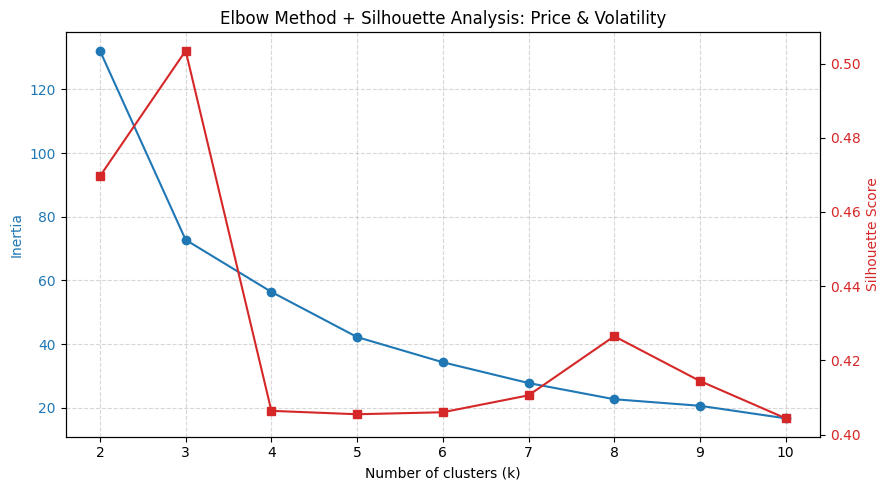

Optimal number of clusters according to silhouette score: 3


In [198]:
# Create DataFrame combining price and volatility
combined_2f = pd.DataFrame({
    'Avg_Price': price_df.set_index('Stock')['Avg_Price'],
    'Monthly_Volatility': volatility['Monthly_Volatility']
}).dropna()

# Scale the features (necessary because of different units)
scaler_2f = StandardScaler()
X_2f_scaled = scaler_2f.fit_transform(combined_2f)

# Range of clusters (silhouette requires at least 2)
K_range = range(2, 11)
inertia = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_2f_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_2f_scaled, labels))

# Plot both metrics with a secondary y‑axis
fig, ax1 = plt.subplots(figsize=(9, 5))

color = 'tab:blue'
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia', color=color)
ax1.plot(K_range, inertia, 'o-', color=color, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()  # second y‑axis
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, silhouette_scores, 's-', color=color, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow Method + Silhouette Analysis: Price & Volatility', fontsize=12)
fig.tight_layout()
plt.show()

# Optimal k based on silhouette score
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters according to silhouette score: {optimal_k}")

### K-mean Approach

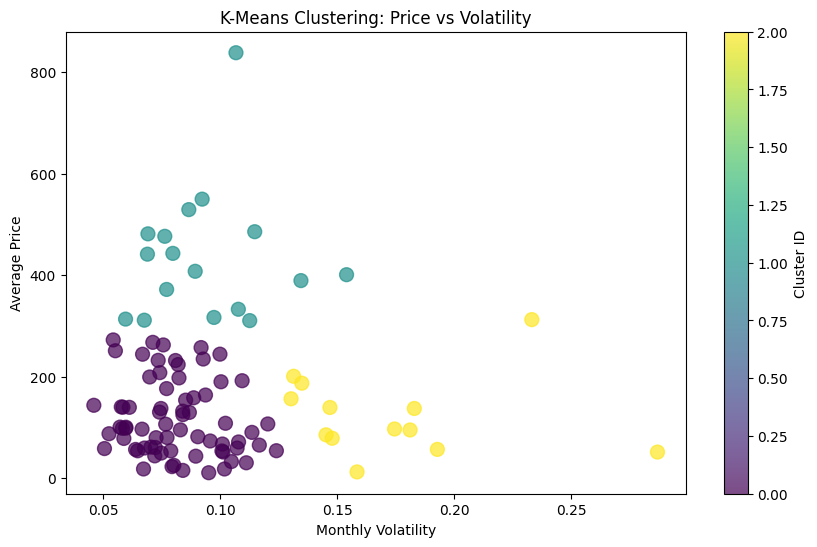

In [199]:
# Taking Optimal K=3

n_clusters_2f = 3
km_2f = KMeans(n_clusters=n_clusters_2f, random_state=42, n_init=10)
km_labels_2f = km_2f.fit_predict(X_2f_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(combined_2f['Monthly_Volatility'], combined_2f['Avg_Price'],
            c=km_labels_2f, cmap='viridis', s=100, alpha=0.7)
plt.title('K-Means Clustering: Price vs Volatility')
plt.xlabel('Monthly Volatility')
plt.ylabel('Average Price')
plt.colorbar(label='Cluster ID')
plt.show()

### Deep Clustering

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


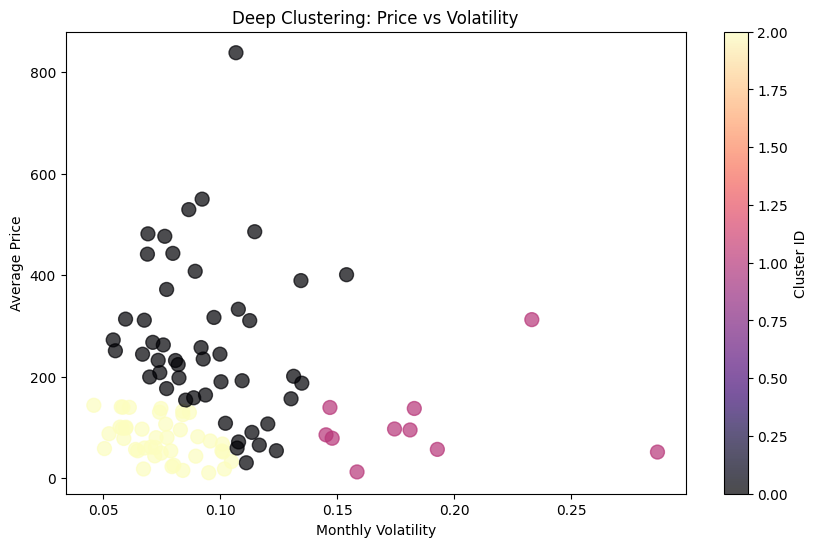

In [200]:
# Autoencoder Architecture (Input dim = 2)

input_dim_2 = 2
latent_dim_2 = 1 

input_l = layers.Input(shape=(input_dim_2,))
enc = layers.Dense(16, activation='relu')(input_l)
enc = layers.Dense(8, activation='relu')(enc)
lat = layers.Dense(latent_dim_2, activation='linear')(enc) # Latent Space
dec = layers.Dense(8, activation='relu')(lat)
dec = layers.Dense(16, activation='relu')(dec)
out = layers.Dense(input_dim_2, activation='linear')(dec)

autoencoder_2f = models.Model(input_l, out)
encoder_2f = models.Model(input_l, lat)
autoencoder_2f.compile(optimizer='adam', loss='mse')

# Train the model
autoencoder_2f.fit(X_2f_scaled, X_2f_scaled, epochs=100, batch_size=16, verbose=0)

# Clustering based on Latent Features
X_latent_2f = encoder_2f.predict(X_2f_scaled)
deep_labels_2f = KMeans(n_clusters=n_clusters_2f, random_state=42).fit_predict(X_latent_2f)

# Plotting Deep Clustering Results
plt.figure(figsize=(10, 6))
plt.scatter(combined_2f['Monthly_Volatility'], combined_2f['Avg_Price'],
            c=deep_labels_2f, cmap='magma', s=100, alpha=0.7)
plt.title('Deep Clustering: Price vs Volatility')
plt.xlabel('Monthly Volatility')
plt.ylabel('Average Price')
plt.colorbar(label='Cluster ID')
plt.show()

In [201]:
# Silhouette Score for K-Mean
km_score_2f = silhouette_score(X_2f_scaled, km_labels_2f)

# Silhouette Score for Deep Clustering
deep_score_2f = silhouette_score(X_latent_2f, deep_labels_2f)


print(f"--- Silhouette Scores (2 Features: Price & Volatility) ---")


# --- Comparison Table ---
comparison_dict = {
    "Model": ["K-Means (2F)", "Deep Clustering (2F)"],
    "Silhouette Score": [km_score_2f, deep_score_2f]
}
comparison_df = pd.DataFrame(comparison_dict)
print("\nComparison Summary:")
print(comparison_df)

--- Silhouette Scores (2 Features: Price & Volatility) ---

Comparison Summary:
                  Model  Silhouette Score
0          K-Means (2F)          0.503468
1  Deep Clustering (2F)          0.622887


## Annual Return vs Annual Volatility:

------------------------------------------------------
------------------------------------------------------
Annual Return and Annual Volatility are the most fundamental metrics used to evaluate the Risk-Reward profile of an investment. While Annual Return measures the total gain or loss of an asset over a year, Annual Volatility quantifies the uncertainty or risk associated with those returns.

Using these two features for clustering allows us to categorize companies based on their performance efficiency:

##### High Return – Low Volatility: High-performing, stable assets 

##### Low Return – High Volatility: Underperforming, risky assets

##### High Return – High Volatility: High-growth but aggressive assets.

This classification is crucial for portfolio optimization as it helps in identifying assets that offer the best return for a given level of risk.

------------------------------------------------------
------------------------------------------------------

In [202]:
# Calculating Log Returns
log_returns = np.log(prices_df / prices_df.shift(1)).dropna()

# Annual Return
# trading days = 252
annual_return = log_returns.mean() * 252

# Annual Volatility
annual_volatility = log_returns.std() * np.sqrt(252)

# Putting into a DataFrame
advanced_features = pd.DataFrame({
    'Annual_Return': annual_return,
    'Annual_Volatility': annual_volatility
})

In [203]:
advanced_features

,Annual_Return,Annual_Volatility
CHTR,-0.117911,0.394821
FOXA,0.337661,0.261579
MTCH,-0.041703,0.371650
PSKY,0.013875,0.522964
TTWO,0.170234,0.287593
...,...,...
D,0.209919,0.213085
ES,0.158242,0.246507
LNT,0.229127,0.175648
PEG,0.170378,0.205277


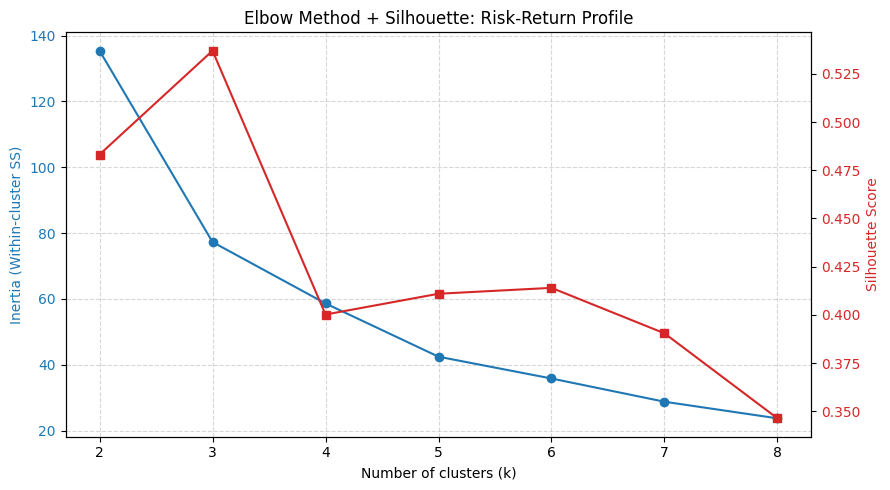

Optimal number of clusters according to silhouette score: 3


In [204]:
# Preparing Data (Log Return සහ Annual Volatility)
X_advanced = advanced_features[['Annual_Return', 'Annual_Volatility']].dropna()

# Scaling (This is mandatory because the values of Return and Volatility are in different ranges)
scaler_adv = StandardScaler()
X_adv_scaled = scaler_adv.fit_transform(X_advanced)

# Range of clusters (silhouette requires at least 2)
K_range = range(2, 9)   # from 2 to 8 clusters (you can extend to 10 if desired)
inertia = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_adv_scaled)
    inertia.append(kmeans.inertia_)
    sil = silhouette_score(X_adv_scaled, labels)
    silhouette_scores.append(sil)

# Plot inertia and silhouette on the same figure with dual axes
fig, ax1 = plt.subplots(figsize=(9, 5))

color = 'tab:blue'
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia (Within-cluster SS)', color=color)
ax1.plot(K_range, inertia, 'o-', color=color, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()  # second y‑axis for silhouette score
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, silhouette_scores, 's-', color=color, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow Method + Silhouette: Risk-Return Profile', fontsize=12)
fig.tight_layout()
plt.show()

# Find optimal k based on silhouette score
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters according to silhouette score: {optimal_k}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


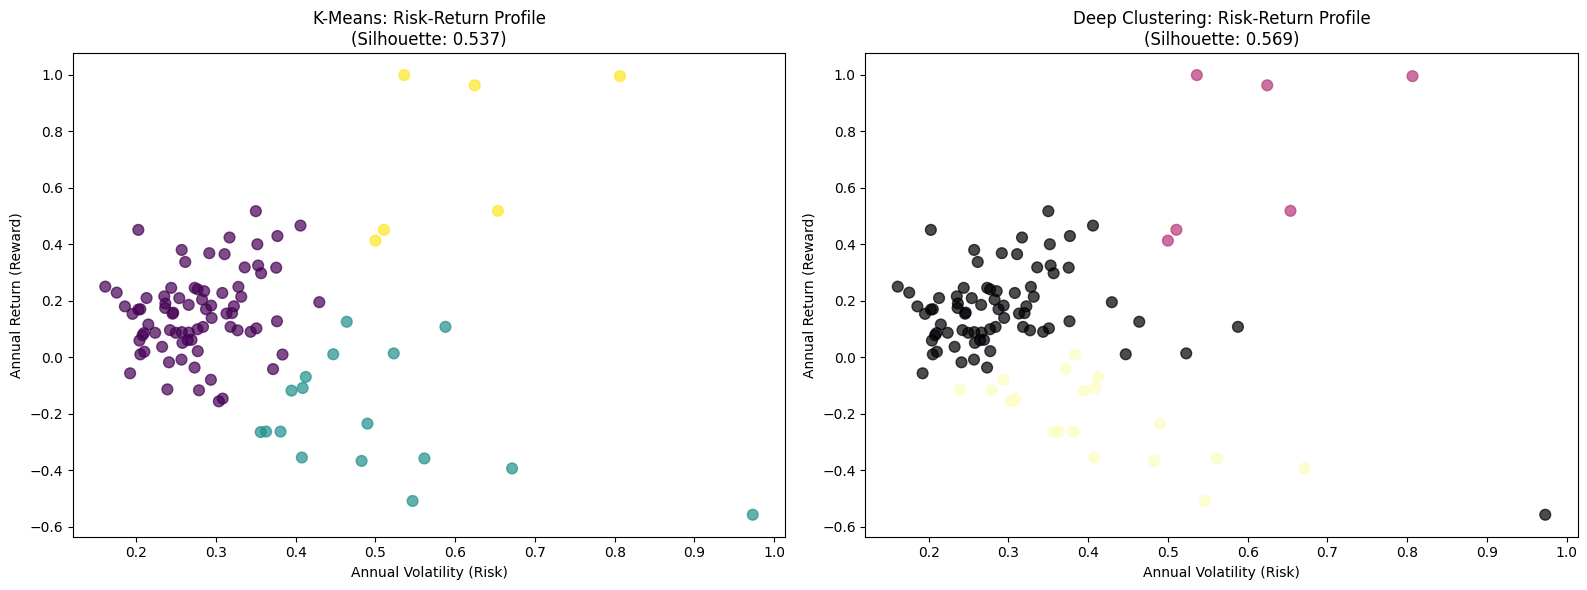

K-Means Score: 0.5369528783939616
Deep Clustering Score: 0.5693970322608948


In [205]:
# Optimal K=3
n_clusters_adv = 3

# K-Means Clustering
kmeans_adv = KMeans(n_clusters=n_clusters_adv, random_state=42, n_init=10)
km_labels_adv = kmeans_adv.fit_predict(X_adv_scaled)
km_score_adv = silhouette_score(X_adv_scaled, km_labels_adv)

#-----------------------------------------------------------------------------------------------

# Deep Clustering (Autoencoder)
input_dim_adv = 2 
latent_dim_adv = 1

input_layer = layers.Input(shape=(input_dim_adv,))
enc = layers.Dense(16, activation='relu')(input_layer)
enc = layers.Dense(8, activation='relu')(enc)
latent = layers.Dense(latent_dim_adv, activation='linear')(enc)
dec = layers.Dense(8, activation='relu')(latent)
dec = layers.Dense(16, activation='relu')(dec)
output_layer = layers.Dense(input_dim_adv, activation='linear')(dec)

autoencoder_adv = models.Model(input_layer, output_layer)
encoder_adv = models.Model(input_layer, latent)
autoencoder_adv.compile(optimizer='adam', loss='mse')

# Train the autoencoder
autoencoder_adv.fit(X_adv_scaled, X_adv_scaled, epochs=100, batch_size=16, verbose=0)

# Clustering based on Latent Space 
X_latent_adv = encoder_adv.predict(X_adv_scaled)
deep_labels_adv = KMeans(n_clusters=n_clusters_adv, random_state=42).fit_predict(X_latent_adv)
deep_score_adv = silhouette_score(X_latent_adv, deep_labels_adv)

#-----------------------------------------------------------------------------------------------

# Visualisation
plt.figure(figsize=(16, 6))

# K-Means Plot
plt.subplot(1, 2, 1)
plt.scatter(advanced_features['Annual_Volatility'], advanced_features['Annual_Return'],
            c=km_labels_adv, cmap='viridis', s=60, alpha=0.7)
plt.title(f'K-Means: Risk-Return Profile\n(Silhouette: {round(km_score_adv, 3)})')
plt.xlabel('Annual Volatility (Risk)')
plt.ylabel('Annual Return (Reward)')

#-----------------------------------------------------------------------------------------------

# Deep Clustering Plot
plt.subplot(1, 2, 2)
plt.scatter(advanced_features['Annual_Volatility'], advanced_features['Annual_Return'],
            c=deep_labels_adv, cmap='magma', s=60, alpha=0.7)
plt.title(f'Deep Clustering: Risk-Return Profile\n(Silhouette: {round(deep_score_adv, 3)})')
plt.xlabel('Annual Volatility (Risk)')
plt.ylabel('Annual Return (Reward)')

plt.tight_layout()
plt.show()

print(f"K-Means Score: {km_score_adv}")
print(f"Deep Clustering Score: {deep_score_adv}")

<h2 style="color:blue;">Advanced Multi-Feature Clustering</h2>


-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
Multi feature clustering allows for the analysis of more than two factors (for example, price, volatility, and returns) at once. It can identify complex relationships between companies that are not visible in a simple graph, and it helps to more accurately group (cluster) companies that are similar in terms of business sector, financial stability, and risk profile. In short, using a wide range of data points can provide a deeper and clearer picture of the true nature of the market.

-------------------------------------------------------------------------------
-------------------------------------------------------------------------------

For our multi-feature clustering, we have selected a comprehensive set of indicators to measure the financial health, risk profile, and price behavior of each company from different perspectives:

#### *Annual Return and Volatility:
These represent the company's long-term profitability and risk, capturing the fundamental risk-vs-reward trade-off over an annualized period.

#### *Monthly Volatility:
This identifies short-term price fluctuations and helps in recognizing consistent patterns while minimizing daily "noise" in the data.

#### *Sharpe Ratio:
This measures the efficiency of a company’s return relative to the risk taken, helping to distinguish high-quality growth from high-risk speculation.

#### *Log Average Price:
Used to compare the market value of companies fairly by normalizing for scale, ensuring that high-priced stocks do not distort the clustering results.

#### *Skewness and Kurtosis:
These higher-order moments capture the shape of the return distribution. Skewness identifies asymmetry (potential for large gains vs. losses), while Kurtosis measures "Fat-tail" risk, identifying stocks prone to extreme price jumps or crashes.

#### *Maximum Drawdown (MDD):
This measures the largest peak-to-trough decline in a stock’s price, providing a "worst-case scenario" metric for risk assessment that standard volatility might miss.

#### *Momentum (12-Month & 1-Month):
This measures the velocity of price changes. It helps identify stocks that are trending strongly (Relative Strength), allowing the model to cluster companies based on their current market trajectory and speed.

In [206]:
# Create Advanced Feature DataFrame
advanced_features = pd.DataFrame(index=log_returns.columns)

# ==========================================
# Feature 1: Annualized Return
advanced_features['Annual_Return'] = log_returns.mean() * 252

# ==========================================
# Feature 2: Annualized Volatility
advanced_features['Annual_Volatility'] = log_returns.std() * np.sqrt(252)

# ==========================================
# Feature 3: Monthly Volatility
advanced_features['Monthly_Volatility'] = log_returns.std() * np.sqrt(21)

# ==========================================
# Feature 4: Sharpe Ratio 
risk_free_rate = 0.02  # 2% annual risk-free rate
advanced_features['Sharpe_Ratio'] = (
    advanced_features['Annual_Return'] - risk_free_rate
) / advanced_features['Annual_Volatility']

# ==========================================
# Feature 5: Log Average Price
advanced_features['Log_Avg_Price'] = np.log(prices_df.mean())

# ==========================================
# Feature 6: Skewness
advanced_features['Skewness'] = log_returns.skew()

# ==========================================
# Feature 7: Kurtosis
advanced_features['Kurtosis'] = log_returns.kurt()

# ==========================================
# Feature 8: Maximum Drawdown (MDD)
def get_max_drawdown(series):
    peak = series.cummax()
    drawdown = (series - peak) / peak
    return drawdown.min()

advanced_features['Max_Drawdown'] = prices_df.apply(get_max_drawdown)

# ==========================================
# Feature 9: 12-Month Momentum (Annual Speed)
advanced_features['12M_Momentum'] = (prices_df.iloc[-1] / prices_df.shift(252).iloc[-1]) - 1

# ==========================================
# Feature 10: 1-Month Momentum (Short-term Speed)
advanced_features['1M_Momentum'] = (prices_df.iloc[-1] / prices_df.shift(21).iloc[-1]) - 1

# Remove Missing Values
advanced_features = advanced_features.dropna()

# Display Features
print("\nAdvanced Multi Features Created Successfully!\n")

print(advanced_features.head(10))


Advanced Multi Features Created Successfully!

      Annual_Return  Annual_Volatility  Monthly_Volatility  Sharpe_Ratio  \
CHTR      -0.117911           0.394821            0.113975     -0.349299   
FOXA       0.337661           0.261579            0.075511      1.214398   
MTCH      -0.041703           0.371650            0.107286     -0.166023   
PSKY       0.013875           0.522964            0.150967     -0.011712   
TTWO       0.170234           0.287593            0.083021      0.522383   
APTV       0.009846           0.383543            0.110719     -0.026475   
CMG       -0.262856           0.362958            0.104777     -0.779309   
DPZ       -0.116696           0.278808            0.080485     -0.490287   
GM         0.325120           0.352976            0.101895      0.864422   
HLT        0.215874           0.235293            0.067923      0.832470   

      Log_Avg_Price  Skewness   Kurtosis  Max_Drawdown  12M_Momentum  \
CHTR       5.738108 -0.482706  13.861784   

In [207]:
from sklearn.decomposition import PCA

# Scaling
scaler_multi = StandardScaler()
X_multi_scaled = scaler_multi.fit_transform(advanced_features[['Annual_Return', 'Annual_Volatility', 'Monthly_Volatility', 'Sharpe_Ratio', 'Log_Avg_Price','Skewness','Kurtosis','Max_Drawdown','12M_Momentum','1M_Momentum',]].values)

# Reducing all 10 features to 2 dimensions (Principal Components) using PCA.
# Noise reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_multi_scaled)

print("Data cleaning by PCA is complete!")

Data cleaning by PCA is complete!


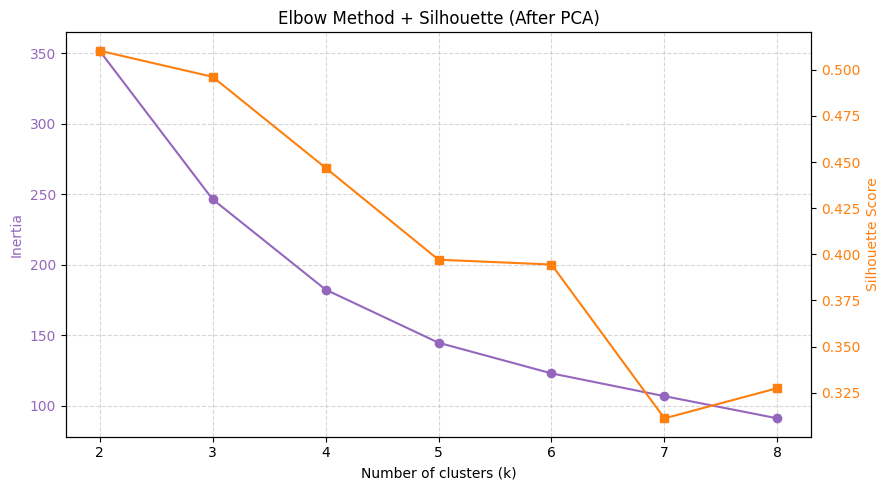

Optimal number of clusters according to silhouette score: 2


In [208]:
# Range of clusters (silhouette requires at least 2)
K_range = range(2, 9)   # you can adjust the upper bound as needed
inertia_pca = []
silhouette_pca = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    inertia_pca.append(kmeans.inertia_)
    sil = silhouette_score(X_pca, labels)
    silhouette_pca.append(sil)

# Plot both metrics with a secondary y‑axis
fig, ax1 = plt.subplots(figsize=(9, 5))

color = 'tab:purple'
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia', color=color)
ax1.plot(K_range, inertia_pca, 'o-', color=color, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()  # second y‑axis
color = 'tab:orange'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, silhouette_pca, 's-', color=color, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow Method + Silhouette (After PCA)', fontsize=12)
fig.tight_layout()
plt.show()

# Find optimal k based on silhouette score
optimal_k = K_range[np.argmax(silhouette_pca)]
print(f"Optimal number of clusters according to silhouette score: {optimal_k}")

In [209]:
# Optimal K=2
n_clusters_final = 2

#-----------------------------------------------------------------------------------------------
# Multi-Feature K-Means (On PCA Data)
km_final = KMeans(n_clusters=n_clusters_final, random_state=42, n_init=10)
km_labels_final = km_final.fit_predict(X_pca)

# Silhoutte score
km_score_final = silhouette_score(X_pca, km_labels_final)


#-----------------------------------------------------------------------------------------------
# Multi-Feature Deep Clustering (On PCA Data)
# Now the input_dim is 2 (because PCA was done)
input_dim_pca = 2 
latent_dim = 1 

input_layer = layers.Input(shape=(input_dim_pca,))
encoded = layers.Dense(16, activation='relu')(input_layer)
latent = layers.Dense(latent_dim, activation='linear')(encoded)
decoded = layers.Dense(16, activation='relu')(latent)
output_layer = layers.Dense(input_dim_pca, activation='linear')(decoded)

autoencoder_final = models.Model(input_layer, output_layer)
encoder_final = models.Model(input_layer, latent)
autoencoder_final.compile(optimizer='adam', loss='mse')

autoencoder_final.fit(X_pca, X_pca, epochs=100, batch_size=16, verbose=0)

X_latent_final = encoder_final.predict(X_pca)
deep_km_final = KMeans(n_clusters=n_clusters_final, random_state=42, n_init=10)
deep_labels_final = deep_km_final.fit_predict(X_latent_final)
deep_score_final = silhouette_score(X_latent_final, deep_labels_final)

# Creating a DataFrame with Clustering Results
clustering_results_df = pd.DataFrame({
    'Ticker': advanced_features.index,
    'KMeans_Cluster': km_labels_final,
    'Deep_Clustering_Cluster': deep_labels_final
})

# Showing the table (first 10 rows)
print("="*50)
print(f"{'STOCK CLUSTERING RESULTS SUMMARY':^50}")
print("="*50)
display(clustering_results_df.sort_values(by='KMeans_Cluster').head(10))

# Number of stocks belonging to each cluster
print("\n" + "="*30)
print("Stocks Count per Cluster")
print("="*30)
print("\n[K-Means Clusters]:")
print(clustering_results_df['KMeans_Cluster'].value_counts().sort_index())

print("\n[Deep Clustering Clusters]:")
print(clustering_results_df['Deep_Clustering_Cluster'].value_counts().sort_index())

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
         STOCK CLUSTERING RESULTS SUMMARY         


,Ticker,KMeans_Cluster,Deep_Clustering_Cluster
0,CHTR,0,0
41,BAX,0,1
43,CRL,0,1
44,DXCM,0,1
48,MRNA,0,1
50,TECH,0,0
63,PAYC,0,1
69,AKAM,0,0
70,APP,0,1
71,CRWD,0,0



Stocks Count per Cluster

[K-Means Clusters]:
KMeans_Cluster
0    22
1    78
Name: count, dtype: int64

[Deep Clustering Clusters]:
Deep_Clustering_Cluster
0    87
1    13
Name: count, dtype: int64


In [210]:
# Displaying the list of stocks belonging to each Cluster separately

print("="*60)
print(f"{'STOCKS LISTED BY CLUSTERS (K-Means)':^60}")
print("="*60)

# According to K-Means results
for cluster_id in range(n_clusters_final):
    stocks_in_cluster = advanced_features.index[km_labels_final == cluster_id].tolist()
    print(f"\n[K-Means Cluster {cluster_id}] ({len(stocks_in_cluster)} stocks):")
    print(", ".join(stocks_in_cluster))

print("\n" + "="*60)
print(f"{'STOCKS LISTED BY CLUSTERS (Deep Clustering)':^60}")
print("="*60)

# According to Deep Clustering results
for cluster_id in range(n_clusters_final):
    stocks_in_cluster = advanced_features.index[deep_labels_final == cluster_id].tolist()
    print(f"\n[Deep Clustering Cluster {cluster_id}] ({len(stocks_in_cluster)} stocks):")
    print(", ".join(stocks_in_cluster))

            STOCKS LISTED BY CLUSTERS (K-Means)             

[K-Means Cluster 0] (22 stocks):
CHTR, PSKY, CMG, DG, BRO, FISV, BAX, CRL, DXCM, MRNA, TECH, PAYC, AKAM, APP, CRWD, EPAM, GDDY, SMCI, TYL, ALB, LYB, VST

[K-Means Cluster 1] (78 stocks):
FOXA, MTCH, TTWO, APTV, DPZ, GM, HLT, MAR, RL, TSCO, YUM, CHD, HSY, KR, MNST, SJM, TSN, CTRA, EXE, OKE, TRGP, AFL, AMP, BAC, CFG, CPAY, HBAN, IVZ, L, MS, PFG, RF, SYF, V, A, CAH, HCA, INCY, LLY, RMD, VTRS, ADP, BA, CHRW, DAL, EME, FDX, GEV, HUBB, J, LII, NDSN, PWR, SNA, UAL, VLTO, AAPL, IBM, KEYS, MSFT, NVDA, PLTR, TDY, CF, ECL, PKG, VMC, CBRE, DOC, FRT, MAA, SBAC, WELL, ATO, D, ES, LNT, PEG

        STOCKS LISTED BY CLUSTERS (Deep Clustering)         

[Deep Clustering Cluster 0] (87 stocks):
CHTR, FOXA, MTCH, PSKY, TTWO, APTV, DPZ, GM, HLT, MAR, RL, TSCO, YUM, CHD, HSY, KR, MNST, SJM, TSN, CTRA, EXE, OKE, TRGP, AFL, AMP, BAC, BRO, CFG, CPAY, HBAN, IVZ, L, MS, PFG, RF, SYF, V, A, CAH, HCA, INCY, LLY, RMD, TECH, VTRS, ADP, BA, CHRW, DAL, EME

Optimized K-Means Score (After PCA): 0.5103
Optimized Deep Clustering Score (After PCA): 0.7376


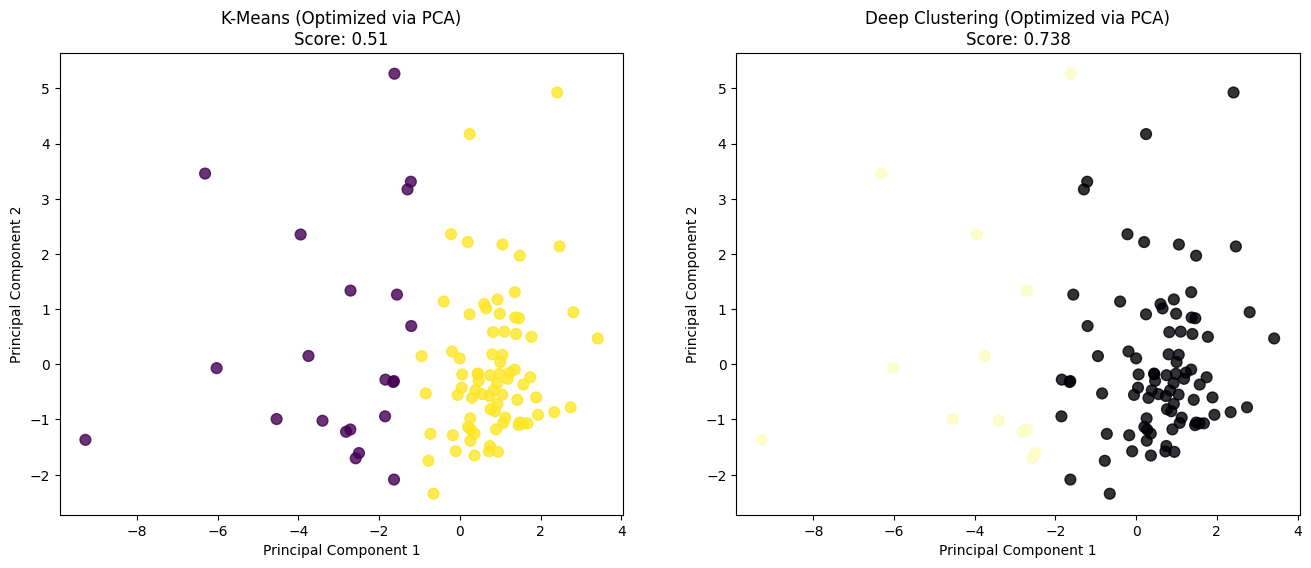

In [211]:
#----------------------------------------------------------------------------------------------
# Comparison Results
print(f"Optimized K-Means Score (After PCA): {km_score_final:.4f}")
print(f"Optimized Deep Clustering Score (After PCA): {deep_score_final:.4f}")

# Visualization
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels_final, cmap='viridis', s=60, alpha=0.8)
plt.title(f'K-Means (Optimized via PCA)\nScore: {round(km_score_final, 3)}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

#----------------------------------------------------------------------------------------------
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=deep_labels_final, cmap='magma', s=60, alpha=0.8)
plt.title(f'Deep Clustering (Optimized via PCA)\nScore: {round(deep_score_final, 3)}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

       PCA FEATURE LOADINGS (CONTRIBUTION)        


,PC1,PC2
Annual_Return,0.342201,0.407700
Annual_Volatility,-0.321720,0.508586
Monthly_Volatility,-0.321720,0.508586
Sharpe_Ratio,0.393623,0.322349
Log_Avg_Price,0.031103,-0.019242
Skewness,0.321320,0.119000
Kurtosis,-0.321252,-0.024710
Max_Drawdown,0.429095,-0.246579
12M_Momentum,0.285611,0.360087
1M_Momentum,0.218723,0.083348


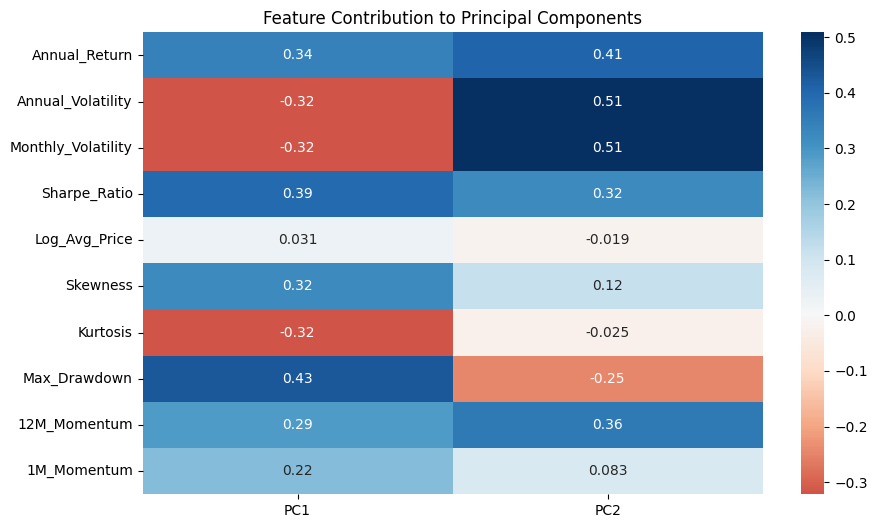

The feature that contributes the most to PC1: Max_Drawdown (Value: 0.4291)
The feature that contributes the most to PC1: Monthly_Volatility (Value: 0.5086)


In [212]:
import seaborn as sns

# Getting PCA Loadings
# pca.components_ shows how features contribute to each component.
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=['Annual_Return', 'Annual_Volatility', 'Monthly_Volatility', 'Sharpe_Ratio', 
           'Log_Avg_Price', 'Skewness', 'Kurtosis', 'Max_Drawdown', '12M_Momentum', '1M_Momentum']
)

print("="*50)
print(f"{'PCA FEATURE LOADINGS (CONTRIBUTION)':^50}")
print("="*50)
display(loadings)

# Drawing a Heatmap 
plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0)
plt.title('Feature Contribution to Principal Components')
plt.show()

# Obtaining the feature that has the greatest impact on PC1 and PC2 individually
for col in loadings.columns:
    top_feature = loadings[col].abs().idxmax()
    importance = loadings.loc[top_feature, col]
    print(f"The feature that contributes the most to PC1: {top_feature} (Value: {importance:.4f})")

--- Silhouette Score Comparison Table (Final Summary) ---


,Experiment,Features Used,K-Means Score,Deep Learning Score
0,Single Feature (Volatility),Monthly Volatility,0.6913,0.7319
1,Two Features (Price & Volatility),"Avg_Price, Monthly_Volatility",0.5035,0.6229
2,Two Features (Risk & Return),"Annual_Return, Annual_Volatility",0.5370,0.5694
3,Optimized Multi-Feature (PCA),10 Features (Reduced to 2D via PCA),0.5103,0.7376


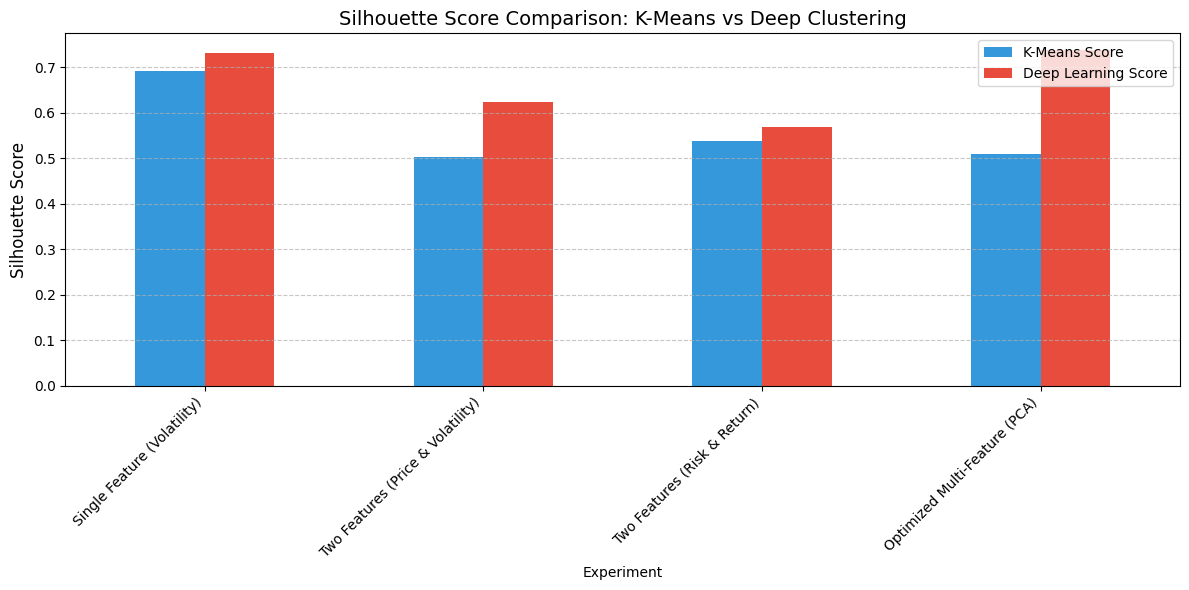

In [213]:
# In this section, we consolidate the previously calculated financial metrics into a single feature set.
comparison_data = [
    {
        "Experiment": "Single Feature (Volatility)",
        "Features Used": "Monthly Volatility",
        "K-Means Score": km_score, 
        "Deep Learning Score": deep_score
    },
    {
        "Experiment": "Two Features (Price & Volatility)",
        "Features Used": "Avg_Price, Monthly_Volatility",
        "K-Means Score": km_score_2f, 
        "Deep Learning Score": deep_score_2f
    },
    {
        "Experiment": "Two Features (Risk & Return)",
        "Features Used": "Annual_Return, Annual_Volatility",
        "K-Means Score": km_score_adv, 
        "Deep Learning Score": deep_score_adv
    },
    {
        "Experiment": "Optimized Multi-Feature (PCA)",
        "Features Used": "10 Features (Reduced to 2D via PCA)",
        "K-Means Score": km_score_final, 
        "Deep Learning Score": deep_score_final
    }
]

# Creating a DataFrame 
df_comparison = pd.DataFrame(comparison_data)

# Showing Silhouette Score Table
print("--- Silhouette Score Comparison Table (Final Summary) ---")
display(df_comparison.round(4))

# Comparison with a graph
df_comparison.plot(x='Experiment', y=['K-Means Score', 'Deep Learning Score'], 
                   kind='bar', figsize=(12, 6), color=['#3498db', '#e74c3c'])
plt.title('Silhouette Score Comparison: K-Means vs Deep Clustering', fontsize=14)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## --------------------------------------------------------------------------------
<h2 style="color:blue;">Portfolio Construction & Cluster Interpretation</h2>

## --------------------------------------------------------------------------------

### Why We Chose Deep Clustering (Autoencoder + K-Means)

### 1) Higher Silhouette Score
Deep Clustering achieved a higher Silhouette Score compared to standard K-Means.
This indicates:
#####                    Better intra-cluster cohesion
#####                    Better inter-cluster separation
Therefore, the clustering structure is more well-defined.

### 2) Capturing Non-Linear Structure
Standard K-Means assumes spherical clusters and relies on Euclidean distance in the original feature space.
The Autoencoder performs non-linear dimensionality reduction, transforming the data into a latent representation where complex relationships are preserved.
Applying K-Means in this latent space allows identification of clusters that are not linearly separable in the original space.

### 3) Improved Portfolio Diversification
More accurately separated clusters imply that assets grouped together have stronger similarity patterns.
Selecting stocks across distinct clusters reduces correlation concentration risk and enhances diversification benefits in portfolio construction.

                 CLUSTER STRATEGY ANALYSIS                  


,Cluster,Annual_Return,Annual_Volatility,Sharpe_Ratio
0,0,0.177566,0.307761,0.501102
1,1,-0.199648,0.518679,-0.503167



Proposed Investment Allocation:
Cluster 0: 70.0% of the total capital
Cluster 1: 30.0% of the total capital


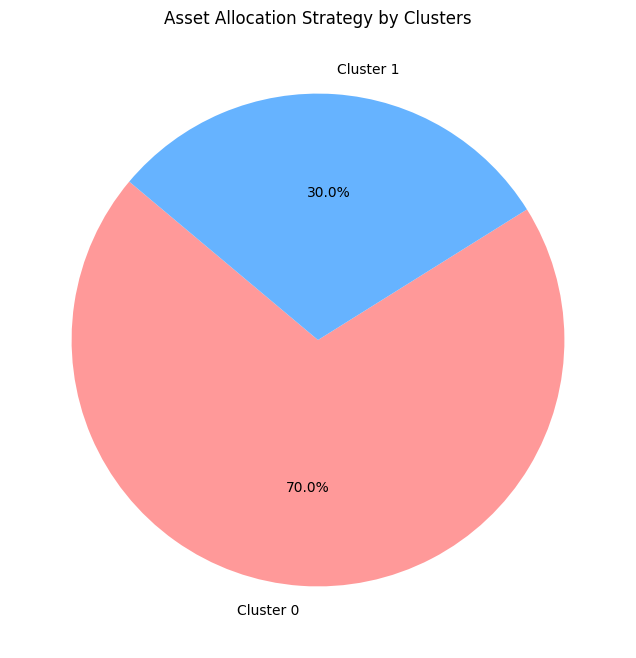

In [214]:
# Summary of the general properties of each cluster (based on Deep Clustering labels)
strategy_df = advanced_features.copy()
strategy_df['Cluster'] = deep_labels_final

# Sumamry Table
summary_stats = strategy_df.groupby('Cluster').agg({
    'Annual_Return': 'mean',
    'Annual_Volatility': 'mean',
    'Sharpe_Ratio': 'mean'
}).reset_index()

print("="*60)
print(f"{'CLUSTER STRATEGY ANALYSIS':^60}")
print("="*60)
display(summary_stats)


# Giving more weight to the cluster with the highest Sharpe Ratio
cluster_weights = {0: 0.70, 1: 0.30}

print("\nProposed Investment Allocation:")
for c, w in cluster_weights.items():
    print(f"Cluster {c}: {w*100}% of the total capital")

# Displaying Allocation in a Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(cluster_weights.values(), labels=[f'Cluster {k}' for k in cluster_weights.keys()], 
        autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Asset Allocation Strategy by Clusters')


['Image of Asset Allocation Pie Chart']

plt.show()

#### *The cluster weights were assigned based on their relative Sharpe Ratios, which measure risk-adjusted return.

#### *The cluster with the highest Sharpe Ratio was given the largest weight (70%) because it provides the highest expected return per unit of risk, making it the most efficient cluster. Allocating a larger portion of capital to this cluster improves the overall portfolio’s risk-return efficiency.

#### *The remaining weight (30%) were allocated to the other cluster to maintain diversification benefits and reduce concentration risk, ensuring the portfolio is not overly dependent on a single cluster.

In [215]:
# Selecting the 3 stocks with the highest Sharpe Ratio from each cluster
#-------------------------------------------------------------------------------------------------------

final_portfolio_stocks = []

for cluster_id in range(n_clusters_final):
    # Taking only the stocks related to that cluster and sorting them according to the Sharpe Ratio
    top_stocks = strategy_df[strategy_df['Cluster'] == cluster_id].sort_values(by='Sharpe_Ratio', ascending=False).head(3)
    final_portfolio_stocks.extend(top_stocks.index.tolist())

print("="*60)
print(f"{'FINAL SELECTED STOCKS FOR PORTFOLIO':^60}")
print("="*60)
print(final_portfolio_stocks)

# Table showing details of selected stocks
final_details = strategy_df.loc[final_portfolio_stocks]
display(final_details[['Annual_Return', 'Annual_Volatility', 'Sharpe_Ratio', 'Cluster']])

            FINAL SELECTED STOCKS FOR PORTFOLIO             
['WELL', 'GEV', 'PLTR', 'APP', 'DG', 'CRL']


,Annual_Return,Annual_Volatility,Sharpe_Ratio,Cluster
WELL,0.451207,0.202775,2.126524,0
GEV,0.999183,0.536242,1.826009,0
PLTR,0.963196,0.624518,1.510277,0
APP,0.995455,0.806651,1.209266,1
DG,0.010799,0.447126,-0.020579,1
CRL,-0.234787,0.490006,-0.519968,1


<h3 style="color:green;">-------------------MSR & GMV Portfolios for selected 6 stocks----------------------</h3>


In [216]:
import scipy.optimize as sco

# Data allocation for 6 selected stocks
selected_returns = log_returns[final_portfolio_stocks]
mean_returns = selected_returns.mean() * 252
cov_matrix = selected_returns.cov() * 252
rf = 0.02  # Risk-free rate

# Functions required for optimization
def portfolio_stats(weights):
    weights = np.array(weights)
    port_ret = np.sum(mean_returns * weights)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return np.array([port_ret, port_vol, (port_ret - rf) / port_vol])

# Maximize Sharpe Ratio (MSR)
def min_func_sharpe(weights):
    return -portfolio_stats(weights)[2]

# Minimize Volatility (GMV)
def min_func_variance(weights):
    return portfolio_stats(weights)[1]**2

# Constraints & Bounds
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for x in range(len(final_portfolio_stocks)))
initial_weights = len(final_portfolio_stocks) * [1. / len(final_portfolio_stocks)]

# MSR Portfolio
opt_msr = sco.minimize(min_func_sharpe, initial_weights, method='SLSQP', bounds=bounds, constraints=constraints)
msr_weights = opt_msr['x']
msr_stats = portfolio_stats(msr_weights)

# GMV Portfolio
opt_gmv = sco.minimize(min_func_variance, initial_weights, method='SLSQP', bounds=bounds, constraints=constraints)
gmv_weights = opt_gmv['x']
gmv_stats = portfolio_stats(gmv_weights)

# Resukts Table
comparison_data = {
    'Metric': ['Expected Annual Return', 'Annual Volatility', 'Sharpe Ratio'],
    'MSR Portfolio': [f"{msr_stats[0]:.2%}", f"{msr_stats[1]:.2%}", f"{msr_stats[2]:.4f}"],
    'GMV Portfolio': [f"{gmv_stats[0]:.2%}", f"{gmv_stats[1]:.2%}", f"{gmv_stats[2]:.4f}"]
}
print("\n" + "="*60)
print(f"{'OPTIMIZED PORTFOLIO RESULTS (FOR SELECTED 6 STOCKS)':^60}")
print("="*60)
display(pd.DataFrame(comparison_data))

# View the weights of each stock related to the MSR Portfolio
print("\nWeights for MSR Portfolio:")
for i, stock in enumerate(final_portfolio_stocks):
    print(f"{stock}: {msr_weights[i]:.2%}")

# Viewing the weights of each stock related to the GMV Portfolio
print("\nWeights for GMV Portfolio:")
for i, stock in enumerate(final_portfolio_stocks):
    print(f"{stock}: {gmv_weights[i]:.2%}")    


    OPTIMIZED PORTFOLIO RESULTS (FOR SELECTED 6 STOCKS)     


,Metric,MSR Portfolio,GMV Portfolio
0,Expected Annual Return,59.33%,36.54%
1,Annual Volatility,20.89%,17.18%
2,Sharpe Ratio,2.7437,2.0108



Weights for MSR Portfolio:
WELL: 70.79%
GEV: 18.32%
PLTR: 8.61%
APP: 0.78%
DG: 1.51%
CRL: 0.00%

Weights for GMV Portfolio:
WELL: 67.76%
GEV: 5.81%
PLTR: 2.37%
APP: 0.00%
DG: 14.34%
CRL: 9.71%


### Optimal utility portfolio for selcted 6 stocks----------------------------------

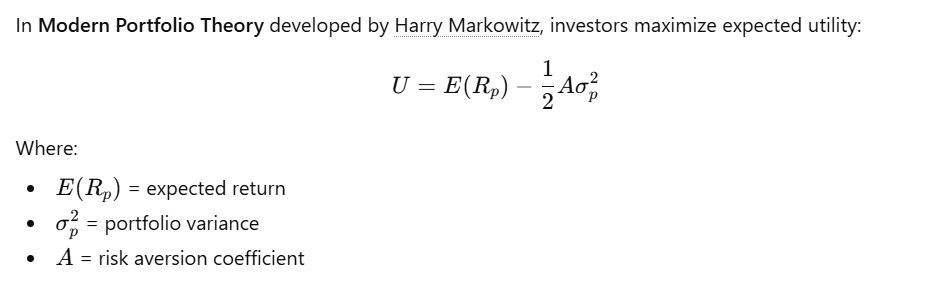


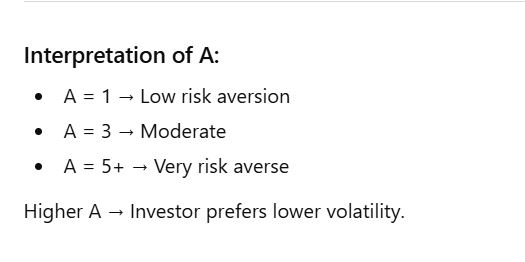

In [217]:
# Utility Function: Return - 0.5 * A * Variance
def min_func_utility(weights, A):
    stats = portfolio_stats(weights)
    return -(stats[0] - 0.5 * A * stats[1]**2)

# Risk Aversion for A=1, 3, 5
risk_aversions = [1, 3, 5]
utility_results = {}

print("="*60)
print(f"{'UTILITY MAXIMIZATION RESULTS (A=1, 3, 5)':^60}")
print("="*60)

for A in risk_aversions:
    res = sco.minimize(min_func_utility, initial_weights, args=(A,), 
                       method='SLSQP', bounds=bounds, constraints=constraints)
    u_stats = portfolio_stats(res['x'])
    utility_results[A] = {'weights': res['x'], 'stats': u_stats, 'utility': u_stats[0] - 0.5 * A * u_stats[1]**2}
    
    print(f"\nFor Risk Aversion A = {A}:")
    print(f"   Expected Return: {u_stats[0]:.2%}")
    print(f"   Annual Volatility: {u_stats[1]:.2%}")
    print(f"   Utility Score: {utility_results[A]['utility']:.4f}")


# Displaying Weights for each Risk Aversion Level as a Table
weights_list = []

for A in risk_aversions:
    w_dict = {'Risk Aversion (A)': A}
    for i, ticker in enumerate(final_portfolio_stocks):
        w_dict[ticker] = f"{utility_results[A]['weights'][i]*100:.2f}%"
    weights_list.append(w_dict)

# -------------------------------------------------------------------------------------------------------------------------
utility_weights_df = pd.DataFrame(weights_list)
print("\n" + "="*80)
print(f"{'OPTIMAL WEIGHTS DISTRIBUTION FOR A = 1, 3, 5':^80}")
print("="*80)
display(utility_weights_df.set_index('Risk Aversion (A)'))    

          UTILITY MAXIMIZATION RESULTS (A=1, 3, 5)          

For Risk Aversion A = 1:
   Expected Return: 99.10%
   Annual Volatility: 48.43%
   Utility Score: 0.8737

For Risk Aversion A = 3:
   Expected Return: 90.51%
   Annual Volatility: 41.19%
   Utility Score: 0.6506

For Risk Aversion A = 5:
   Expected Return: 74.69%
   Annual Volatility: 29.21%
   Utility Score: 0.5337

                  OPTIMAL WEIGHTS DISTRIBUTION FOR A = 1, 3, 5                  


,WELL,GEV,PLTR,APP,DG,CRL
Risk Aversion (A),,,,,,
1,0.00%,66.90%,21.55%,11.55%,0.00%,0.00%
3,15.55%,52.80%,23.85%,7.80%,0.00%,0.00%
5,44.96%,34.97%,15.95%,4.13%,0.00%,0.00%


### Visualization-------------------------------------------------------

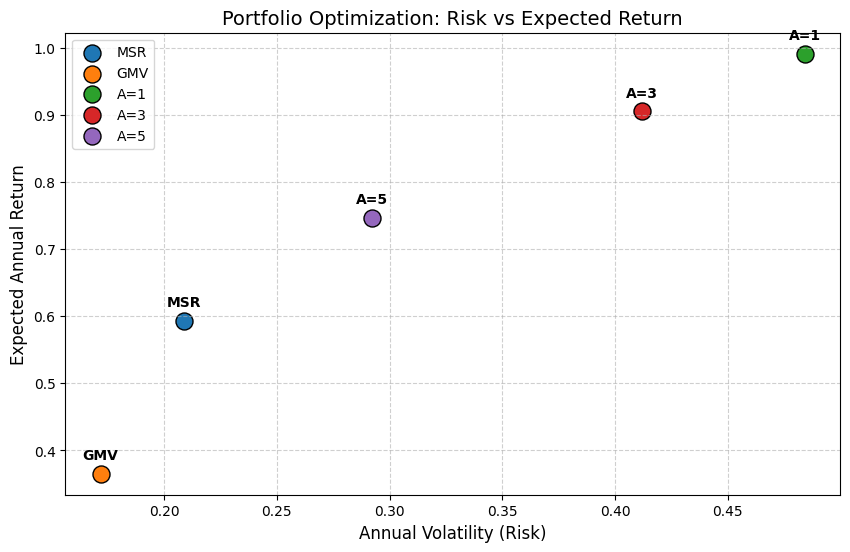

In [218]:
# Data Collection
plot_data = {
    'MSR': {'ret': msr_stats[0], 'vol': msr_stats[1]},
    'GMV': {'ret': gmv_stats[0], 'vol': gmv_stats[1]},
    'A=1': {'ret': utility_results[1]['stats'][0], 'vol': utility_results[1]['stats'][1]},
    'A=3': {'ret': utility_results[3]['stats'][0], 'vol': utility_results[3]['stats'][1]},
    'A=5': {'ret': utility_results[5]['stats'][0], 'vol': utility_results[5]['stats'][1]}
}

# Plotting
plt.figure(figsize=(10, 6))

for name, data in plot_data.items():
    plt.scatter(data['vol'], data['ret'], s=150, edgecolors='black', label=name)
    plt.annotate(name, (data['vol'], data['ret']), textcoords="offset points", 
                 xytext=(0,10), ha='center', fontweight='bold')

plt.title('Portfolio Optimization: Risk vs Expected Return', fontsize=14)
plt.xlabel('Annual Volatility (Risk)', fontsize=12)
plt.ylabel('Expected Annual Return', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

### Portfolio Performance

In [219]:
# Investment amount
initial_investment = 10_000_000 

# Summarizing data for each strategy - Corrected access for utility_results
strategies = {
    'MSR (Max Sharpe Ratio)': [msr_stats[0], msr_stats[1]],
    'GMV (Global Min Variance)': [gmv_stats[0], gmv_stats[1]],
    'Utility A=1': [utility_results[1]['stats'][0], utility_results[1]['stats'][1]],
    'Utility A=3': [utility_results[3]['stats'][0], utility_results[3]['stats'][1]],
    'Utility A=5': [utility_results[5]['stats'][0], utility_results[5]['stats'][1]]
}

investment_results = []

for name, stats in strategies.items():
    annual_return = stats[0]
    annual_volatility = stats[1]
    
    # Expected Annual Profit
    expected_profit = initial_investment * annual_return
    
    # Risk - Value at Risk (95% Confidence)
    # Formula: Investment * (Return - 1.645 * Volatility)
    VaR_95 = initial_investment * (annual_return - 1.645 * annual_volatility)
    
    investment_results.append({
        'Strategy': name,
        'Expected Annual Profit (LKR)': f"Rs. {expected_profit:,.2f}",
        'Annual Volatility (%)': f"{annual_volatility:.2%}",
        'Max Potential Loss (95% VaR)': f"Rs. {abs(min(0, VaR_95)):,.2f}"
    })

# Displaying results as a table
investment_df = pd.DataFrame(investment_results)
print("="*95)
print(f"{'INVESTMENT PERFORMANCE FOR LKR 10 MILLION':^95}")
print("="*95)
display(investment_df)

                           INVESTMENT PERFORMANCE FOR LKR 10 MILLION                           


,Strategy,Expected Annual Profit (LKR),Annual Volatility (%),Max Potential Loss (95% VaR)
0,MSR (Max Sharpe Ratio),"Rs. 5,932,874.32",20.89%,Rs. 0.00
1,GMV (Global Min Variance),"Rs. 3,654,036.35",17.18%,Rs. 0.00
2,Utility A=1,"Rs. 9,909,961.48",48.43%,Rs. 0.00
3,Utility A=3,"Rs. 9,051,028.72",41.19%,Rs. 0.00
4,Utility A=5,"Rs. 7,469,348.88",29.21%,Rs. 0.00


## --------------------------------------------------------------

<h2 style="color:blue;">BENCHMARK & INVESTMENT ANALYSIS</h2>

## --------------------------------------------------------------

In this study, the S&P 500 Index (^GSPC) is used as the benchmark to evaluate the performance of our portfolios. As it tracks 500 of the largest companies in the U.S., it serves as a proxy for the overall market. By comparing our selected 9-stock portfolios against this index, we can verify if our clustering and optimization methods successfully delivered higher returns or better risk management than a standard market investment.

In [220]:
# Obtaining Benchmark (S&P 500) Data
benchmark_ticker = "^GSPC"
df_benchmark = yf.download(benchmark_ticker, start=start_date, end=end_date)
benchmark_data = df_benchmark.iloc[:, 0] 
benchmark_returns = benchmark_data.pct_change().dropna()

# Annual Data
rf = 0.02
bench_ann_ret = benchmark_returns.mean() * 252
bench_ann_vol = benchmark_returns.std() * np.sqrt(252)

# Investment Analysis (Rs. 10 Million)
initial_investment = 10_000_000
\
all_strategies = {
    'MSR Portfolio': [msr_stats[0], msr_stats[1]],
    'GMV Portfolio': [gmv_stats[0], gmv_stats[1]],
    'Utility (A=1)': [utility_results[1]['stats'][0], utility_results[1]['stats'][1]],
    'Utility (A=3)': [utility_results[3]['stats'][0], utility_results[3]['stats'][1]],
    'Utility (A=5)': [utility_results[5]['stats'][0], utility_results[5]['stats'][1]],
    'S&P 500 (Benchmark)': [bench_ann_ret, bench_ann_vol]
}

comparison_list = []

for name, stats in all_strategies.items():
    ret = stats[0]
    vol = stats[1]
    profit = initial_investment * ret
    sharpe = (ret - rf) / vol
    # 95% Confidence Value at Risk
    var_95 = initial_investment * (ret - 1.645 * vol)
    
    comparison_list.append({
        'Strategy': name,
        'Expected Annual Profit': f"Rs. {profit:,.2f}",
        'Annual Risk (Vol)': f"{vol:.2%}",
        'Sharpe Ratio': f"{sharpe:.4f}",
        'Max Loss (95% VaR)': f"Rs. {abs(min(0, var_95)):,.2f}"
    })

# Show the dataframe
final_comp_df = pd.DataFrame(comparison_list)
print("="*95)
print(f"{'FINAL PERFORMANCE SUMMARY VS BENCHMARK':^95}")
print("="*95)
display(final_comp_df)

[*********************100%***********************]  1 of 1 completed

                            FINAL PERFORMANCE SUMMARY VS BENCHMARK                             


,Strategy,Expected Annual Profit,Annual Risk (Vol),Sharpe Ratio,Max Loss (95% VaR)
0,MSR Portfolio,"Rs. 5,932,874.32",20.89%,2.7437,Rs. 0.00
1,GMV Portfolio,"Rs. 3,654,036.35",17.18%,2.0108,Rs. 0.00
2,Utility (A=1),"Rs. 9,909,961.48",48.43%,2.0051,Rs. 0.00
3,Utility (A=3),"Rs. 9,051,028.72",41.19%,2.1488,Rs. 0.00
4,Utility (A=5),"Rs. 7,469,348.88",29.21%,2.4889,Rs. 0.00
5,S&P 500 (Benchmark),"Rs. 1,744,654.69",16.00%,0.9652,"Rs. 888,039.15"


### Visual Performance Attribution

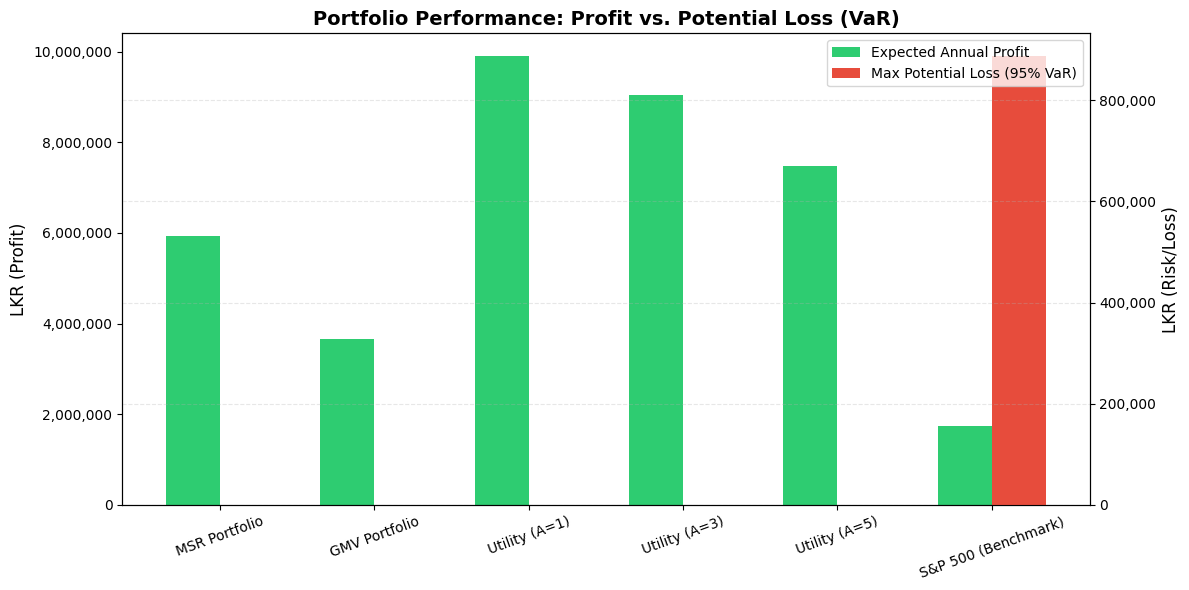

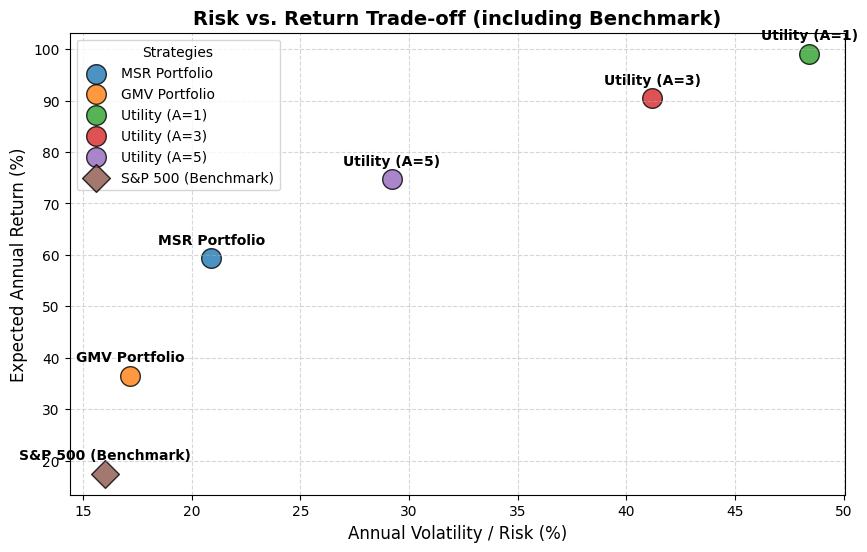

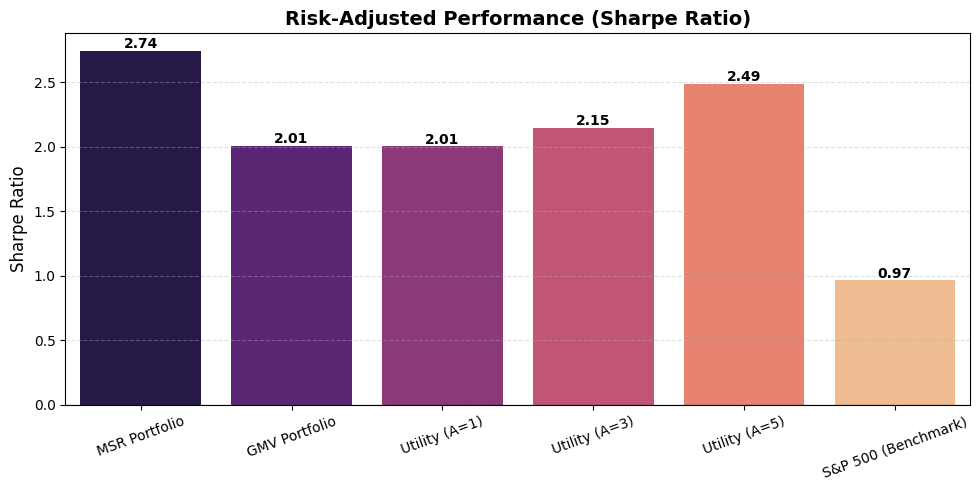

In [221]:
# Data preparation for visualization 
names = list(all_strategies.keys())
profits = [initial_investment * all_strategies[n][0] for n in names]
risks = [all_strategies[n][1] * 100 for n in names] # Percentage
sharpes = [(all_strategies[n][0] - rf) / all_strategies[n][1] for n in names]
vars_95 = [abs(min(0, initial_investment * (all_strategies[n][0] - 1.645 * all_strategies[n][1]))) for n in names]


colors = sns.color_palette("viridis", len(names))

# --- PLOT 1: Expected Profit vs. Potential Loss ---
fig, ax1 = plt.subplots(figsize=(12, 6))

x = np.arange(len(names))
width = 0.35

bar1 = ax1.bar(x - width/2, profits, width, label='Expected Annual Profit', color='#2ecc71')
ax1.set_ylabel('LKR (Profit)', fontsize=12)
ax1.set_title('Portfolio Performance: Profit vs. Potential Loss (VaR)', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=20)
ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

ax2 = ax1.twinx()
bar2 = ax2.bar(x + width/2, vars_95, width, label='Max Potential Loss (95% VaR)', color='#e74c3c')
ax2.set_ylabel('LKR (Risk/Loss)', fontsize=12)
ax2.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# --- PLOT 2: Risk-Return Scatter Plot (The Modern Portfolio View) ---
plt.figure(figsize=(10, 6))

for i, name in enumerate(names):
    marker = 'o' if 'Benchmark' not in name else 'D'
    plt.scatter(risks[i], all_strategies[name][0]*100, s=200, label=name, alpha=0.8, edgecolors='black', marker=marker)
    plt.annotate(name, (risks[i], all_strategies[name][0]*100), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.xlabel('Annual Volatility / Risk (%)', fontsize=12)
plt.ylabel('Expected Annual Return (%)', fontsize=12)
plt.title('Risk vs. Return Trade-off (including Benchmark)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Strategies")
plt.show()

# --- PLOT 3: Sharpe Ratio (Efficiency) ---
plt.figure(figsize=(10, 5))
sns.barplot(x=names, y=sharpes, palette="magma")
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Sharpe Ratio', fontsize=12)
plt.title('Risk-Adjusted Performance (Sharpe Ratio)', fontsize=14, fontweight='bold')
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Overwriting the values ​​bar
for i, v in enumerate(sharpes):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## ---------------------------------------------------------------------

<h2 style="color:blue;">Comparative Analysis of Optimized Portfolios across the Full Asset Universe</h2>

## ---------------------------------------------------------------------

<h3 style="color:green;">1) Maximum Sharp Ratio Portfolio (MSR) & Global Minimum Variance Portfolio (GMV)</h3>


The MSR portfolio represents the most efficient point on the Efficient Frontier. It is designed to maximize the excess return for every unit of risk taken by the investor. Graphically, it is the unique point where the Capital Market Line (CML) is tangent to the Efficient Frontier. This model is ideal for rational investors seeking to optimize the trade-off between risk and reward.

The GMV portfolio focuses exclusively on risk reduction, ignoring expected returns. It is the leftmost point on the Efficient Frontier, representing the combination of assets that results in the lowest possible portfolio volatility. By utilizing the negative correlations between various stocks, this model aims to create the most stable investment possible, making it suitable for highly risk-averse investors.

In [222]:
from scipy.optimize import minimize

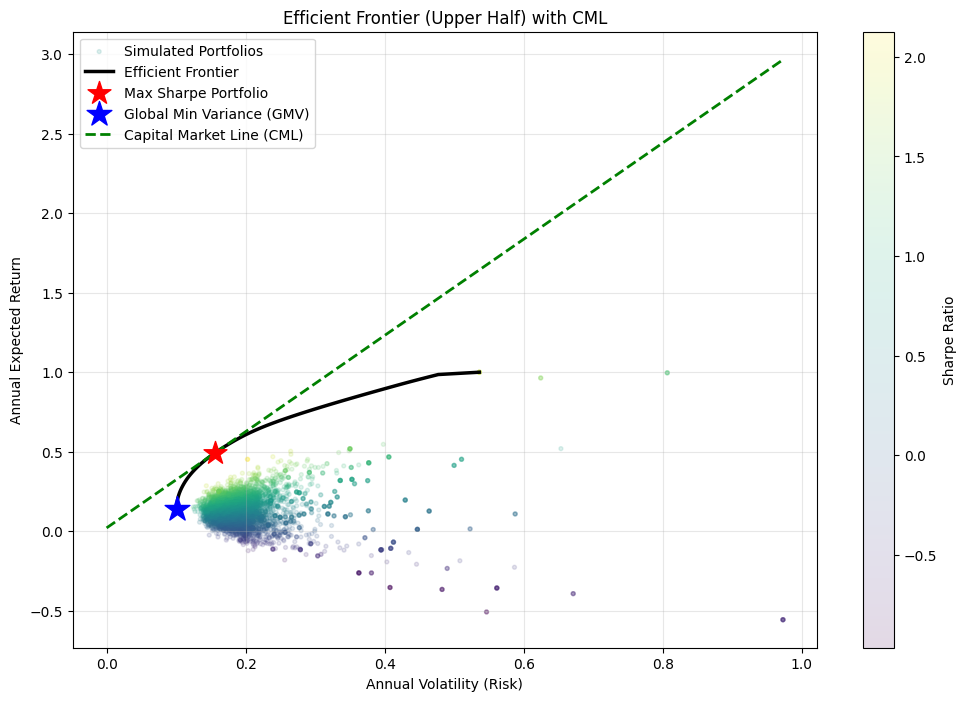

In [223]:
# Data preparation
mu = log_returns.mean() * 252                # annualised expected returns
cov = log_returns.cov() * 252                 # annualised covariance matrix
assets = log_returns.columns.tolist()
n = len(assets)

num_random = 20000                           # number of random portfolios for the cloud
frontier_points = 60                           # number of points on the efficient frontier
rf = 0.02                                       # risk‑free rate

# Portfolio Functions
def port_return(w):
    return np.dot(w, mu)

def port_var(w):
    """Return portfolio variance (annualised)."""
    return w.T @ cov @ w

def neg_sharpe(w):
    """Negative Sharpe ratio (for minimisation)."""
    return -(port_return(w) - rf) / np.sqrt(port_var(w))

# -----------------------------------------------------------------------------
# Simulate random portfolios 
rets_sim, vols_sim, sharpes_sim = [], [], []

# Parameters
n_diverse = 15000      # number of diversified portfolios (uniform)
n_sparse = 5000        # number of sparse portfolios (Dirichlet)
n_extreme = 500        # number of single‑asset portfolios

# Diversified portfolios (uniform random)
for _ in range(n_diverse):
    w = np.random.random(n)
    w /= w.sum()
    r = port_return(w)
    v = np.sqrt(port_var(w))
    s = (r - rf) / v
    rets_sim.append(r)
    vols_sim.append(v)
    sharpes_sim.append(s)

# Sparse portfolios 
alpha = 0.1  # concentration parameter (<1 gives sparse)
for _ in range(n_sparse):
    w = np.random.dirichlet([alpha] * n)
    r = port_return(w)
    v = np.sqrt(port_var(w))
    s = (r - rf) / v
    rets_sim.append(r)
    vols_sim.append(v)
    sharpes_sim.append(s)

# Extreme portfolios (single asset)
for _ in range(n_extreme):
    idx = np.random.randint(n)
    w = np.zeros(n)
    w[idx] = 1.0
    r = port_return(w)
    v = np.sqrt(port_var(w))
    s = (r - rf) / v
    rets_sim.append(r)
    vols_sim.append(v)
    sharpes_sim.append(s)

# Convert to arrays
rets_sim = np.array(rets_sim)
vols_sim = np.array(vols_sim)
sharpes_sim = np.array(sharpes_sim)


# Constraints and bounds
bounds = tuple((0, 1) for _ in range(n))
cons_sum = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
w0 = np.ones(n) / n

# -----------------------------------------------------------------------------
# Maximum Sharpe Ratio portfolio (tangency portfolio)
# -----------------------------------------------------------------------------
opt_sharpe = minimize(neg_sharpe, w0, method='SLSQP',
                      bounds=bounds, constraints=cons_sum)
w_star = opt_sharpe.x
ret_star = port_return(w_star)
vol_star = np.sqrt(port_var(w_star))

# -----------------------------------------------------------------------------
# Global Minimum Variance (GMV) portfolio
# -----------------------------------------------------------------------------
gmv = minimize(port_var, w0, method='SLSQP',
               bounds=bounds, constraints=cons_sum)
w_gmv = gmv.x # Weights for GMV
ret_gmv = port_return(w_gmv) # Return for GMV
vol_gmv = np.sqrt(port_var(w_gmv)) # Volatility for GMV

# -----------------------------------------------------------------------------
# Efficient Frontier
# -----------------------------------------------------------------------------
target_returns = np.linspace(ret_gmv, mu.max(), frontier_points)
frontier_vols = []
prev_w = w_star                                  # start from the tangency weights

for tr in target_returns:
    # Constraint: portfolio return must equal target return
    cons_tr = (cons_sum, {'type': 'eq', 'fun': lambda w: port_return(w) - tr})
    res = minimize(port_var, prev_w, method='SLSQP',
                   bounds=bounds, constraints=cons_tr)
    if res.success:
        frontier_vols.append(np.sqrt(res.fun))
        prev_w = res.x                           # warm start for next iteration
    else:
        frontier_vols.append(np.nan)              # mark as invalid

frontier_vols = np.array(frontier_vols)

# -----------------------------------------------------------------------------
# Capital Market Line (CML)
# -----------------------------------------------------------------------------
cml_x = np.linspace(0, max(vols_sim), 100)
cml_y = rf + ((ret_star - rf) / vol_star) * cml_x



#------------------------------------------------------------------------------
# Plotting
#------------------------------------------------------------------------------

plt.figure(figsize=(12, 8))

# Cloud of simulated portfolios
sc = plt.scatter(vols_sim, rets_sim, c=sharpes_sim, cmap='viridis',
                 s=8, alpha=0.15, label='Simulated Portfolios')

# Efficient Frontier
valid = ~np.isnan(frontier_vols)
plt.plot(frontier_vols[valid], target_returns[valid],
         'k-', linewidth=2.5, label='Efficient Frontier')

# Maximum Sharpe portfolio (Red Star)
plt.scatter(vol_star, ret_star, color='red', marker='*',
            s=300, label='Max Sharpe Portfolio', zorder=10)

# Global Minimum Variance portfolio (Blue Star)
plt.scatter(vol_gmv, ret_gmv, color='blue', marker='*', s=350, label='Global Min Variance (GMV)', zorder=10)

# Capital Market Line
plt.plot(cml_x, cml_y, color='green', linestyle='--',
         linewidth=2, label='Capital Market Line (CML)')

plt.xlabel('Annual Volatility (Risk)')
plt.ylabel('Annual Expected Return')
plt.title('Efficient Frontier (Upper Half) with CML')
plt.colorbar(sc, label='Sharpe Ratio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Portfolio Details ---------------------------------------------------

In [224]:
# -----------------------------------------------------------------------------
# Portfolio details for MSR
# -----------------------------------------------------------------------------
print("\n" + "="*50)
print(f"{'MAXIMUM SHARPE RATIO PORTFOLIO':^50}")
print("="*50)
print(f"Expected Annual Return : {ret_star*100:.2f}%")
print(f"Annual Risk (Volatility): {vol_star*100:.2f}%")
print(f"Sharpe Ratio           : {(ret_star - rf) / vol_star:.2f}")

# Weights table (only holdings with weight > 0.1%)
weights_df = pd.DataFrame({
    'Asset': assets,
    'Weight (%)': w_star * 100,
    'Allocation (10M LKR)': (w_star * 10_000_000).round(2)
})
print("\n" + "-"*50)
print("TOP HOLDINGS (for a 10 million LKR portfolio)")
print("-"*50)
display(weights_df[weights_df['Weight (%)'] > 0.1].sort_values('Weight (%)', ascending=False))


# -----------------------------------------------------------------------------
# Portfolio details for GMV
# -----------------------------------------------------------------------------
print("\n" + "="*50)
print(f"{'GLOBAL MINIMUM VARIANCE (GMV) PORTFOLIO':^50}")
print("="*50)

w_gmv = gmv.x
ret_gmv_val = port_return(w_gmv)
vol_gmv_val = np.sqrt(port_var(w_gmv))

print(f"Expected Annual Return : {ret_gmv_val*100:.2f}%")
print(f"Annual Risk (Volatility): {vol_gmv_val*100:.2f}%")
print(f"Sharpe Ratio           : {(ret_gmv_val - rf) / vol_gmv_val:.2f}")

# Weights table (only holdings with weight > 0.1%)
weights_gmv_df = pd.DataFrame({
    'Asset': assets,
    'Weight (%)': w_gmv * 100,
    'Allocation (10M LKR)': (w_gmv * 10_000_000).round(2)
})

print("\n" + "-"*50)
print("TOP HOLDINGS (for a 10 million LKR portfolio - GMV)")
print("-"*50)
display(weights_gmv_df[weights_gmv_df['Weight (%)'] > 0.1].sort_values('Weight (%)', ascending=False))


          MAXIMUM SHARPE RATIO PORTFOLIO          
Expected Annual Return : 49.05%
Annual Risk (Volatility): 15.55%
Sharpe Ratio           : 3.03

--------------------------------------------------
TOP HOLDINGS (for a 10 million LKR portfolio)
--------------------------------------------------


,Asset,Weight (%),Allocation (10M LKR)
93,WELL,34.578747,3457874.70
94,ATO,13.655975,1365597.53
54,CHRW,12.861808,1286180.75
58,GEV,12.451820,1245181.95
42,CAH,5.524578,552457.80
78,PLTR,4.989883,498988.31
46,INCY,4.474118,447411.79
18,MNST,3.276166,327616.61
1,FOXA,2.777648,277764.75
17,KR,2.446377,244637.70



     GLOBAL MINIMUM VARIANCE (GMV) PORTFOLIO      
Expected Annual Return : 13.86%
Annual Risk (Volatility): 10.07%
Sharpe Ratio           : 1.18

--------------------------------------------------
TOP HOLDINGS (for a 10 million LKR portfolio - GMV)
--------------------------------------------------


,Asset,Weight (%),Allocation (10M LKR)
14,CHD,13.406444,1340644.40
76,MSFT,12.400005,1240000.46
17,KR,9.715942,971594.23
94,ATO,9.395812,939581.24
16,HSY,5.768471,576847.13
97,LNT,5.409453,540945.30
20,TSN,4.450024,445002.36
4,TTWO,4.266185,426618.48
83,CF,3.871407,387140.66
42,CAH,3.668943,366894.26


### Portfolio Performance-----------------------------------------------------------------

In [225]:
# --- Total Portfolio Performance - MSR---

# Key indicators of the portfolio (Annualized Metrics)
total_ret_pct = ret_star * 100
total_vol_pct = vol_star * 100
sharpe_val = (ret_star - rf) / vol_star

# Expected Profit if 10 million is invested
total_capital = 10_000_000
expected_annual_profit_lkr = total_capital * ret_star

print("="*60)
print(f"{'MSR PORTFOLIO INVESTMENT SUMMARY':^60}")
print("="*60)

print(f"1. Total Expected Annual Return  : {total_ret_pct:.2f}%")
print(f"2. Total Annual Risk (Volatility) : {total_vol_pct:.2f}%")
print(f"3. Portfolio Sharpe Ratio        : {sharpe_val:.2f}")

print("-"*60)
print(f"4. Initial Investment Amount     : LKR {total_capital:,.2f}")
print(f"5. Expected Annual Profit        : LKR {expected_annual_profit_lkr:,.2f}")
print(f"6. Projected Total Value (1 Yr)  : LKR {total_capital + expected_annual_profit_lkr:,.2f}")

print("="*60)

              MSR PORTFOLIO INVESTMENT SUMMARY              
1. Total Expected Annual Return  : 49.05%
2. Total Annual Risk (Volatility) : 15.55%
3. Portfolio Sharpe Ratio        : 3.03
------------------------------------------------------------
4. Initial Investment Amount     : LKR 10,000,000.00
5. Expected Annual Profit        : LKR 4,905,140.69
6. Projected Total Value (1 Yr)  : LKR 14,905,140.69


In [226]:
# --- Total GMV Portfolio Performance - GMV ---

# Key indicators of the portfolio (Annualized Metrics)
total_ret_pct_gmv = ret_gmv_val * 100
total_vol_pct_gmv = vol_gmv_val * 100
sharpe_val_gmv = (ret_gmv_val - rf) / vol_gmv_val

# Expected Profit if 10 million is invested
total_capital = 10_000_000
expected_annual_profit_lkr_gmv = total_capital * ret_gmv_val

print("="*60)
print(f"{'GLOBAL MINIMUM VARIANCE (GMV) SUMMARY':^60}")
print("="*60)

print(f"1. Total Expected Annual Return  : {total_ret_pct_gmv:.2f}%")
print(f"2. Total Annual Risk (Volatility) : {total_vol_pct_gmv:.2f}%")
print(f"3. Portfolio Sharpe Ratio        : {sharpe_val_gmv:.2f}")

print("-"*60)
print(f"4. Initial Investment Amount     : LKR {total_capital:,.2f}")
print(f"5. Expected Annual Profit        : LKR {expected_annual_profit_lkr_gmv:,.2f}")
print(f"6. Projected Total Value (1 Yr)  : LKR {total_capital + expected_annual_profit_lkr_gmv:,.2f}")

print("="*60)

           GLOBAL MINIMUM VARIANCE (GMV) SUMMARY            
1. Total Expected Annual Return  : 13.86%
2. Total Annual Risk (Volatility) : 10.07%
3. Portfolio Sharpe Ratio        : 1.18
------------------------------------------------------------
4. Initial Investment Amount     : LKR 10,000,000.00
5. Expected Annual Profit        : LKR 1,385,809.98
6. Projected Total Value (1 Yr)  : LKR 11,385,809.98


<h3 style="color:green;">2) Optimal Utility Portfolio</h3>

This model personalizes the investment strategy by incorporating an individual's Risk Aversion Coefficient (A). It identifies the point where an investor's Indifference Curve is tangent to the Efficient Frontier. For a cautious investor (A=5), the model selects a lower-risk portfolio near the GMV, while for a more aggressive investor (A=1), it moves higher up the curve to capture greater returns. This approach ensures the portfolio aligns with the investor's psychological comfort level regarding market fluctuations.

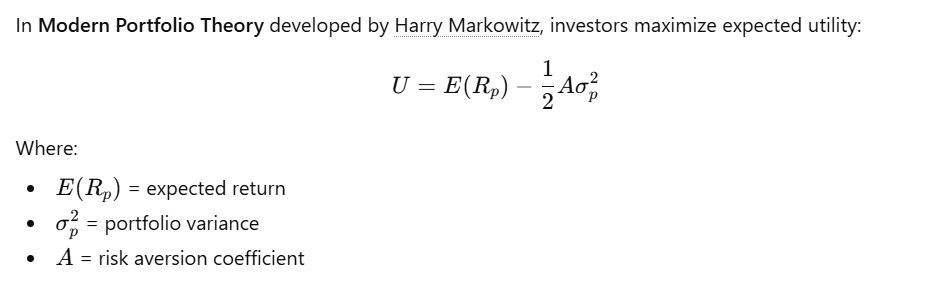


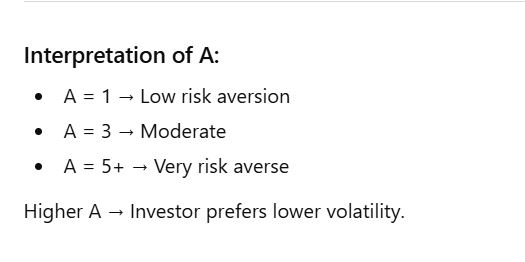

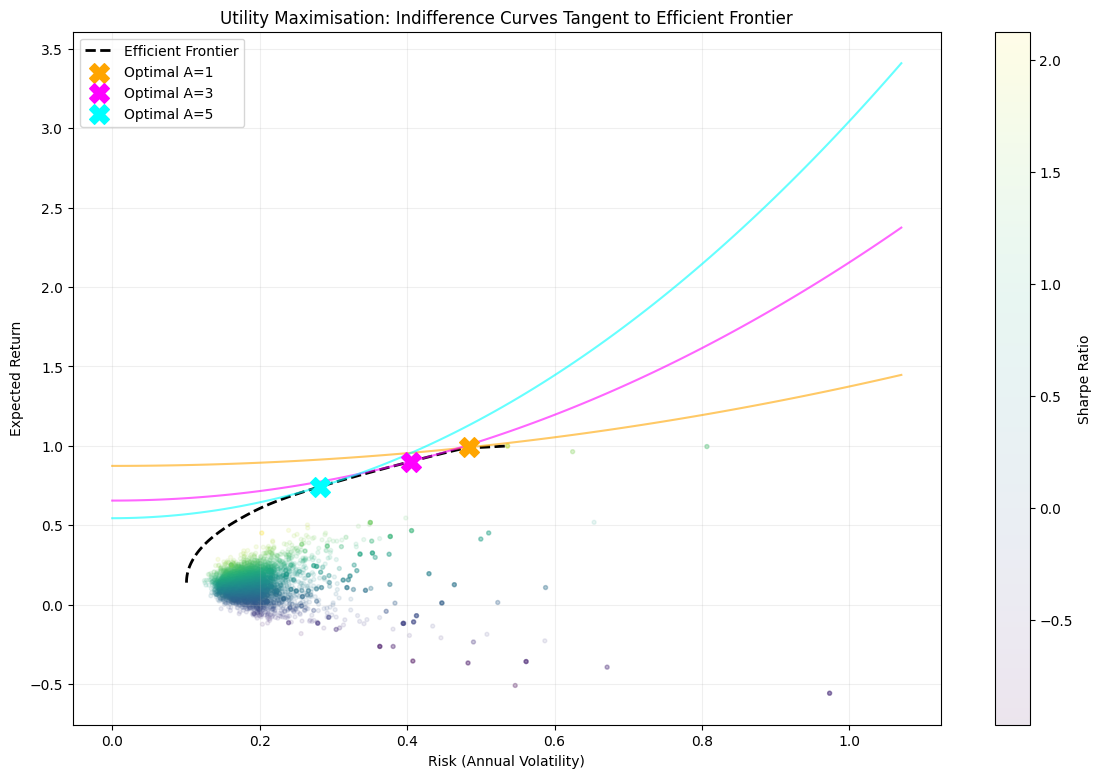


OPTIMAL PORTFOLIOS FOR DIFFERENT RISK AVERSIONS

A = 1
  Return: 99.10%   Volatility: 48.43%   Utility: 0.8737
  Top holdings:
    GEV: 66.9%
    PLTR: 21.6%
    APP: 11.6%

A = 3
  Return: 90.13%   Volatility: 40.49%   Utility: 0.6553
  Top holdings:
    GEV: 51.9%
    PLTR: 23.1%
    CHRW: 14.9%
    APP: 6.9%
    WELL: 3.2%

A = 5
  Return: 74.24%   Volatility: 28.14%   Utility: 0.5444
  Top holdings:
    GEV: 33.9%
    WELL: 30.5%
    CHRW: 17.4%
    PLTR: 15.2%
    APP: 3.0%


In [227]:
# Data Preparation
# mu = log_returns.mean() * 252
# cov = log_returns.cov() * 252
# assets = log_returns.columns.tolist()
# n = len(assets)
rf = 0.02

# Portfolio functions
def port_return(w):
    return np.dot(w, mu)

def port_var(w):
    return w.T @ cov @ w

def port_vol(w):
    return np.sqrt(port_var(w))

# Constraints & bounds
bounds = tuple((0, 1) for _ in range(n))
cons = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
w0 = np.ones(n) / n

# -----------------------------------------------------------------------------
# Compute a smooth efficient frontier 
# -----------------------------------------------------------------------------

# Global Minimum Variance portfolio
def gmv_portfolio():
    res = minimize(port_var, w0, method='SLSQP', bounds=bounds, constraints=cons)
    return res.x, port_return(res.x), np.sqrt(res.fun)

w_gmv, ret_gmv, vol_gmv = gmv_portfolio()

# Target returns from GMV return up to maximum asset return
frontier_points = 60
target_returns = np.linspace(ret_gmv, mu.max(), frontier_points)

# Compute frontier volatilities by minimising variance for each target return
frontier_vols = []
prev_w = w_gmv   # warm start

for tr in target_returns:
    cons_tr = (cons, {'type': 'eq', 'fun': lambda w: port_return(w) - tr})
    res = minimize(port_var, prev_w, method='SLSQP', bounds=bounds, constraints=cons_tr)
    if res.success:
        frontier_vols.append(np.sqrt(res.fun))
        prev_w = res.x
    else:
        frontier_vols.append(np.nan)

frontier_vols = np.array(frontier_vols)
valid = ~np.isnan(frontier_vols)

# -----------------------------------------------------------------------------
# Utility optimisation for different risk aversions
# -----------------------------------------------------------------------------
def objective_utility(w, A):
    """Negative utility (to minimise)."""
    return -(port_return(w) - 0.5 * A * port_var(w))

A_vals = [1, 3, 5]
colors = ['orange', 'magenta', 'cyan']
opt_points = []   # store (vol, ret, A, success)

for A in A_vals:
    res = minimize(objective_utility, w0, args=(A,), method='SLSQP',
                   bounds=bounds, constraints=cons)
    if not res.success:
        print(f"Warning: Optimisation for A={A} did not converge.")
        continue
    w_opt = res.x
    r_opt = port_return(w_opt)
    v_opt = port_vol(w_opt)
    u_opt = -res.fun   # maximum utility
    opt_points.append((v_opt, r_opt, A, u_opt, w_opt))

# -----------------------------------------------------------------------------
# Plotting
# -----------------------------------------------------------------------------
plt.figure(figsize=(14, 9))

# Cloud of simulated portfolios (if available, else skip)
if 'vols_sim' in globals() and 'rets_sim' in globals():
    sc = plt.scatter(vols_sim, rets_sim,
                     c=(np.array(rets_sim)-rf)/np.array(vols_sim),
                     cmap='viridis', s=8, alpha=0.1)
    plt.colorbar(sc, label='Sharpe Ratio')

# Efficient frontier 
plt.plot(frontier_vols[valid], target_returns[valid], 'k--',
         linewidth=2, label='Efficient Frontier')

# Indifference curves and optimal points
vol_range = np.linspace(0.0, max(vols_sim)*1.1, 100) if 'vols_sim' in globals() else np.linspace(0, 0.5, 100)

for (v_opt, r_opt, A, u_opt, w_opt) in opt_points:
    # Plot the optimal point
    plt.scatter(v_opt, r_opt, color=colors[A_vals.index(A)], marker='X',
                s=200, label=f'Optimal A={A}', zorder=20)
    # Indifference curve: Return = u_opt + 0.5*A*vol^2
    indiff_curve = u_opt + 0.5 * A * (vol_range**2)
    plt.plot(vol_range, indiff_curve, color=colors[A_vals.index(A)],
             linestyle='-', alpha=0.6, linewidth=1.5)

plt.xlabel('Risk (Annual Volatility)')
plt.ylabel('Expected Return')
plt.title('Utility Maximisation: Indifference Curves Tangent to Efficient Frontier')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# -----------------------------------------------------------------------------
# Print optimal portfolio details
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("OPTIMAL PORTFOLIOS FOR DIFFERENT RISK AVERSIONS")
print("="*60)
for (v_opt, r_opt, A, u_opt, w_opt) in opt_points:
    print(f"\nA = {A}")
    print(f"  Return: {r_opt*100:.2f}%   Volatility: {v_opt*100:.2f}%   Utility: {u_opt:.4f}")
    # Show top 5 weights
    top_idx = np.argsort(w_opt)[-5:][::-1]
    print("  Top holdings:")
    for i in top_idx:
        if w_opt[i] > 0.01:
            print(f"    {assets[i]}: {w_opt[i]*100:.1f}%")

### Portfolio Performance----------------------------------------------------------------------

In [228]:
# --- Total Utility Portfolio Performance (A=1, 3, 5) ---
total_capital = 10_000_000

print("="*65)
print(f"{'OPTIMAL UTILITY PORTFOLIO INVESTMENT SUMMARY':^65}")
print("="*65)


for i, A in enumerate([1, 3, 5]):
    v_opt_val, r_opt_val, A_val, u_opt_val, w_opt_val = opt_points[i]
    
    total_ret_pct_util = r_opt_val * 100
    total_vol_pct_util = v_opt_val * 100
    sharpe_val_util = (r_opt_val - rf) / v_opt_val
    expected_annual_profit_util = total_capital * r_opt_val
    
    print(f"--- Risk Aversion Level A = {A} ---")
    print(f"1. Total Expected Annual Return   : {total_ret_pct_util:.2f}%")
    print(f"2. Total Annual Risk (Volatility) : {total_vol_pct_util:.2f}%")
    print(f"3. Portfolio Sharpe Ratio         : {sharpe_val_util:.4f}")
    print(f"4. Expected Annual Profit         : LKR {expected_annual_profit_util:,.2f}")
    print(f"5. Projected Total Value (1 Yr)   : LKR {total_capital + expected_annual_profit_util:,.2f}")
    print("-" * 65)

print("="*65)

          OPTIMAL UTILITY PORTFOLIO INVESTMENT SUMMARY           
--- Risk Aversion Level A = 1 ---
1. Total Expected Annual Return   : 99.10%
2. Total Annual Risk (Volatility) : 48.43%
3. Portfolio Sharpe Ratio         : 2.0051
4. Expected Annual Profit         : LKR 9,909,954.91
5. Projected Total Value (1 Yr)   : LKR 19,909,954.91
-----------------------------------------------------------------
--- Risk Aversion Level A = 3 ---
1. Total Expected Annual Return   : 90.13%
2. Total Annual Risk (Volatility) : 40.49%
3. Portfolio Sharpe Ratio         : 2.1763
4. Expected Annual Profit         : LKR 9,012,619.30
5. Projected Total Value (1 Yr)   : LKR 19,012,619.30
-----------------------------------------------------------------
--- Risk Aversion Level A = 5 ---
1. Total Expected Annual Return   : 74.24%
2. Total Annual Risk (Volatility) : 28.14%
3. Portfolio Sharpe Ratio         : 2.5668
4. Expected Annual Profit         : LKR 7,423,730.19
5. Projected Total Value (1 Yr)   : LKR 17,423

## -------------------------------------------------------------------------------------

<h2 style="color:blue;">Comparison among GMV, MSR & Optimal Utility Portfolios</h2>

## -------------------------------------------------------------------------------------

                    FINAL PORTFOLIO COMPARISON SUMMARY                     


,Portfolio Type,Expected Return (%),Annual Risk/Vol (%),Sharpe Ratio
0,Maximum Sharpe Ratio (MSR),49.05,15.55,3.03
1,Global Min Variance (GMV),13.86,10.07,1.18
2,Optimal Utility (A=1),99.10,48.43,2.01
3,Optimal Utility (A=3),90.51,41.19,2.15
4,Optimal Utility (A=5),74.69,29.21,2.49


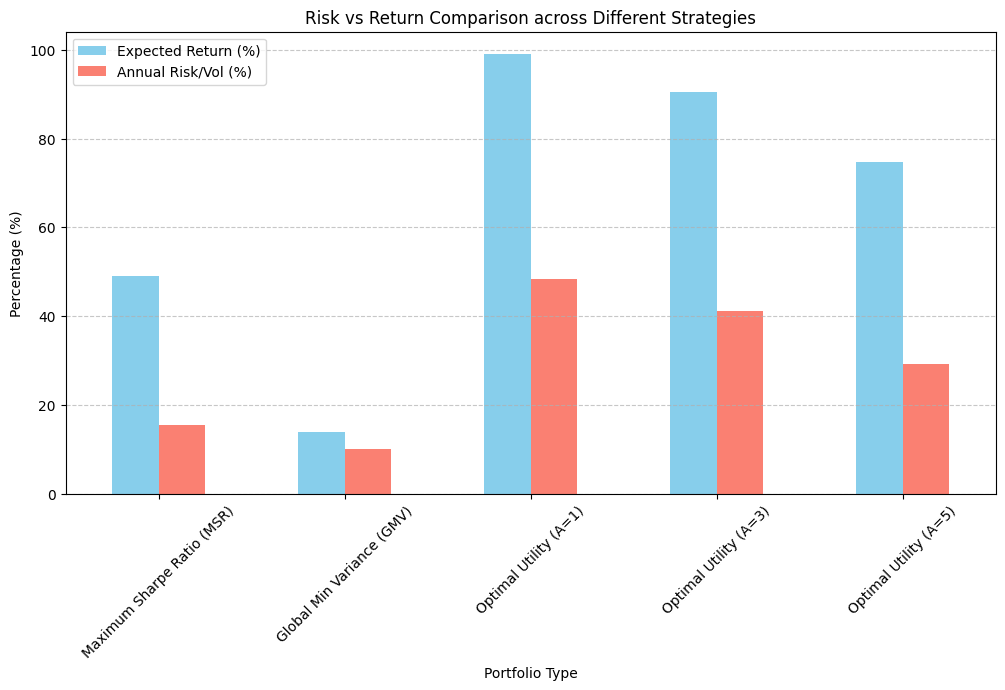

In [229]:
# --- Comparing all portfolio types ---

comparison_data = {
    'Portfolio Type': [
        'Maximum Sharpe Ratio (MSR)', 
        'Global Min Variance (GMV)', 
        'Optimal Utility (A=1)', 
        'Optimal Utility (A=3)', 
        'Optimal Utility (A=5)'
    ],
    'Expected Return (%)': [
        ret_star * 100, 
        ret_gmv * 100, 
        utility_results[1]['stats'][0] * 100, 
        utility_results[3]['stats'][0] * 100, 
        utility_results[5]['stats'][0] * 100
    ],
    'Annual Risk/Vol (%)': [
        vol_star * 100, 
        vol_gmv * 100, 
        utility_results[1]['stats'][1] * 100, 
        utility_results[3]['stats'][1] * 100, 
        utility_results[5]['stats'][1] * 100
    ],
    'Sharpe Ratio': [
        (ret_star - rf) / vol_star,
        (ret_gmv - rf) / vol_gmv,
        (utility_results[1]['stats'][0] - rf) / utility_results[1]['stats'][1],
        (utility_results[3]['stats'][0] - rf) / utility_results[3]['stats'][1],
        (utility_results[5]['stats'][0] - rf) / utility_results[5]['stats'][1]
    ]
}

comparison_df = pd.DataFrame(comparison_data).round(2)

print("="*75)
print(f"{'FINAL PORTFOLIO COMPARISON SUMMARY':^75}")
print("="*75)
display(comparison_df)

# A bar chart showing the relationship between profit and risk
comparison_df.set_index('Portfolio Type')[['Expected Return (%)', 'Annual Risk/Vol (%)']].plot(kind='bar', figsize=(12,6), color=['skyblue', 'salmon'])
plt.title('Risk vs Return Comparison across Different Strategies')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.show()

## --------------------------------------------------------------------------
## Comparative Analysis: Portfolio Performance of Cluster-Based Selection vs. Market Universe
## --------------------------------------------------------------------------

             STRATEGIC COMPARISON: 6 SELECTED STOCKS VS. FULL 100 STOCKS             


Exp. Return (%)                     Risk/Vol (%)  \
Universe      6 Selected Stocks All 100 Stocks 6 Selected Stocks   
Strategy                                                           
GMV Portfolio         36.540363      13.858100         17.177687   
MSR Portfolio         59.328743      49.051407         20.894531   
Utility (A=1)         99.099615      99.099549         48.425479   
Utility (A=3)         90.510287      90.126193         41.191174   
Utility (A=5)         74.693489      74.237302         29.207452   

                                  Sharpe Ratio                 
Universe      All 100 Stocks 6 Selected Stocks All 100 Stocks  
Strategy                                                       
GMV Portfolio      10.073548          2.010769       1.177152  
MSR Portfolio      15.549859          2.743720       3.025841  
Utility (A=1)      48.425340          2.005135       2.005139  
Utility (A=3)      40.493865          2.148768       2.176285  
Utility (A=5)      28.142962          2.488868       2.566798

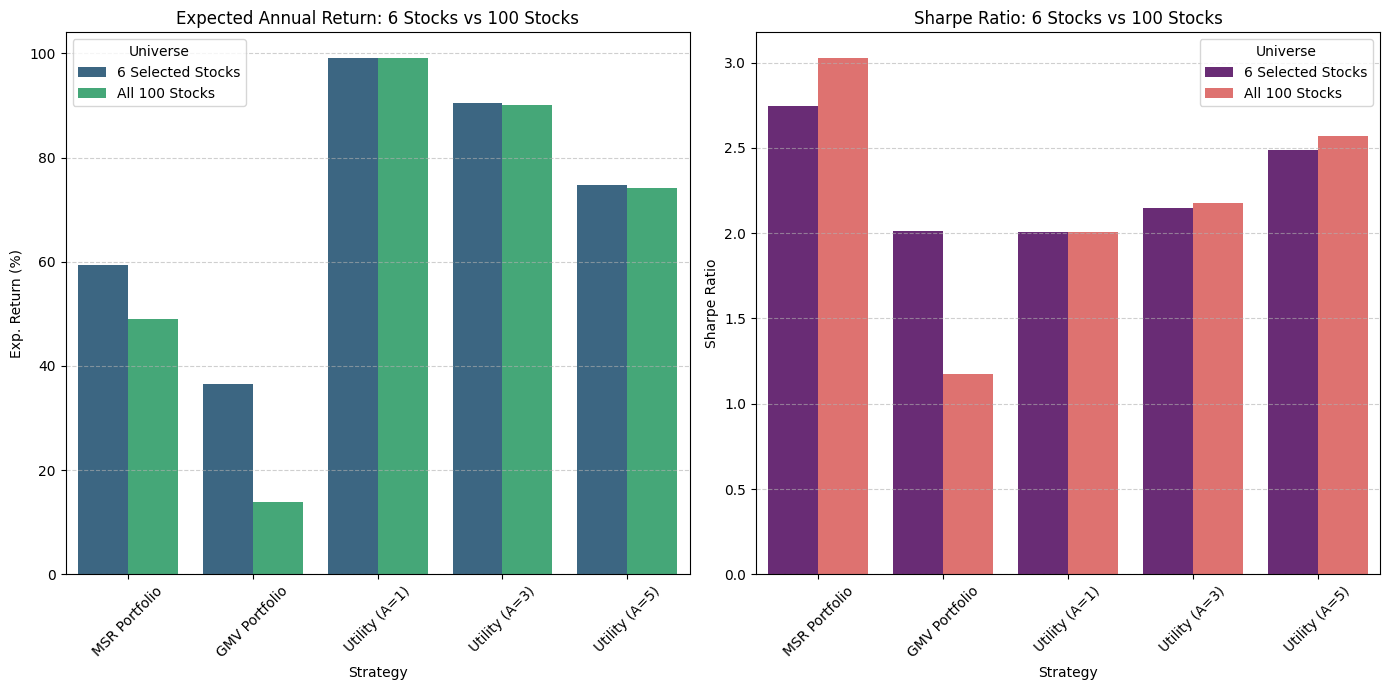

In [230]:
# --- Comparison: 6 Selected Stocks vs. Full 100 Stocks Universe ---

# 100 Stocks Utility Results
# opt_points = [(vol, ret, A, u, weights), ...]
full_utility = {p[2]: (p[1], p[0]) for p in opt_points} 

comparison_list = []

# Strategies to compare
strategies = ['MSR Portfolio', 'GMV Portfolio', 'Utility (A=1)', 'Utility (A=3)', 'Utility (A=5)']

for strategy in strategies:
    # 6 Stocks Data
    if strategy == 'MSR Portfolio':
        ret6, vol6 = msr_stats[0], msr_stats[1]
        ret100, vol100 = ret_star, vol_star
    elif strategy == 'GMV Portfolio':
        ret6, vol6 = gmv_stats[0], gmv_stats[1]
        ret100, vol100 = ret_gmv, vol_gmv
    elif 'Utility' in strategy:
        A = int(strategy.split('=')[1].replace(')', ''))
        ret6, vol6 = utility_results[A]['stats'][0], utility_results[A]['stats'][1]
        ret100, vol100 = full_utility[A][0], full_utility[A][1]

    # Append Results
    comparison_list.append({
        'Strategy': strategy,
        'Universe': '6 Selected Stocks',
        'Exp. Return (%)': ret6 * 100,
        'Risk/Vol (%)': vol6 * 100,
        'Sharpe Ratio': (ret6 - rf) / vol6
    })
    comparison_list.append({
        'Strategy': strategy,
        'Universe': 'All 100 Stocks',
        'Exp. Return (%)': ret100 * 100,
        'Risk/Vol (%)': vol100 * 100,
        'Sharpe Ratio': (ret100 - rf) / vol100
    })

# Convert to DataFrame
final_comparison_df = pd.DataFrame(comparison_list)

# Display Table
print("="*85)
print(f"{'STRATEGIC COMPARISON: 6 SELECTED STOCKS VS. FULL 100 STOCKS':^85}")
print("="*85)
display(final_comparison_df.pivot(index='Strategy', columns='Universe'))

# --- Visualizing the Comparison ---
import seaborn as sns

plt.figure(figsize=(14, 7))

# 1. Expected Return Comparison
plt.subplot(1, 2, 1)
sns.barplot(data=final_comparison_df, x='Strategy', y='Exp. Return (%)', hue='Universe', palette='viridis')
plt.title('Expected Annual Return: 6 Stocks vs 100 Stocks')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 2. Sharpe Ratio Comparison
plt.subplot(1, 2, 2)
sns.barplot(data=final_comparison_df, x='Strategy', y='Sharpe Ratio', hue='Universe', palette='magma')
plt.title('Sharpe Ratio: 6 Stocks vs 100 Stocks')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Conclusion

The analysis shows that the Cluster-based 6-stock portfolio performs competitively against the 100-stock universe. By using Deep Clustering, we have identified a high-performing subset that offers a superior risk-return trade-off with lower management complexity.